In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import xarray as xr
import matplotlib.ticker as ticker


# Read EP flux variable = -($\overline{u'v'}$)j + (${f0 \over \overline{\theta_p}}$ $\overline{v'\theta'}$) k

In [91]:
import numpy as np
import dask.array as da
from dask.diagnostics import ProgressBar

class AtmosphericDiagnostics:
    """
    Perform general atmospheric diagnostics including:
    - Anomalies
    - Eddy Momentum Flux (EMF)
    - Eddy Heat Flux (EHF)
    - Meridional EMF gradient (dEMF/dy)
    """

    def __init__(self, u, v, t, p, z, lat=None, lon=None):
        """
        Parameters:
        - u, v, t, p: Arrays (NumPy or Dask) of shape (time, z, y, x)
        - lat, lon: Optional 1D arrays for latitude and longitude
        """
        self.u = u
        self.v = v
        self.t = t
        self.p = p
        self.z = z

        # constant
        self.g = 9.81

        self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
        self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
        self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

    @staticmethod
    def anomaly(data, axis=-1):
        """Compute the anomaly by subtracting mean along axis."""
        mean = np.mean(data, axis=axis, keepdims=True)
        return data - mean

    @staticmethod
    def compute_if_dask(arr):
        """Compute the result if it's a Dask array."""
        return arr.compute() if isinstance(arr, da.Array) else arr

    @staticmethod
    def EMF_dask(u, v, axis=-1):
        """Eddy Momentum Flux: u'v' (Dask-compatible)."""
        u_prime = u - u.mean(axis=axis, keepdims=True)
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return u_prime * v_prime
        
    # @staticmethod    
    def cal_theta(self):
        """
        Compute potential temperature θ = T * (p0 / p)^(R/Cp) using self.t and self.p
    
        Returns:
        - theta: potential temperature [K], shape same as self.t
        """
        Rd, Cp = 287.0, 1004.0
        exponent = Rd / Cp
        p1d = np.mean(self.p, axis=(0,2,3))
        theta = self.t * (100000 / p1d[np.newaxis,:,np.newaxis,np.newaxis]) ** exponent
        return theta

        
    def EHF_dask(self, t, p, v, axis=-1):
        theta = self.cal_theta()  
        theta_mean = theta.mean(axis=axis, keepdims=True)
        theta_prime = theta - theta_mean
    
        v_prime = v - v.mean(axis=axis, keepdims=True)
        # b = (theta_prime / theta_mean) * self.g
        # b_prime = b - b.mean(axis=axis, keepdims=True)
    
        return v_prime * theta_prime
        # return v_prime * b
        

    def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
        """
        Efficient + accurate meridional gradient of EMF (∂(u'v')/∂y) with Dask support.
    
        Parameters:
        - emf: Array (time, z, y, x), either NumPy or Dask
        - use_dask: If True, compute using Dask (lazy until .compute())
        - progress: If True and use_dask is True, show progress bar
        - chunks: Tuple to use if converting NumPy array to Dask
    
        Returns:
        - dEMF_dy: NumPy array if computed, or Dask array if lazy
        """
        # Ensure emf is a Dask array
        emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
    
        # Compute dy between latitudes in meters
        R = 6.371e6
        lat_rad = np.radians(self.lat)
        dy = np.gradient(lat_rad) * R  # shape (y,)
        dy_dask = da.from_array(dy, chunks=(chunks[2],))
        dy_broadcast = dy_dask[None, None, :, None]  # shape (1, 1, y, 1)
    
        # Compute meridional gradient using Dask
        d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast
    
        if use_dask:
            if progress:
                from dask.diagnostics import ProgressBar
                print("dEMF_dy progress:")
                with ProgressBar():
                    return d_emf_dy.compute()
            else:
                return d_emf_dy  # Lazy result
        else:
            # Fallback to NumPy gradient
            emf_np = emf.compute() if isinstance(emf, da.Array) else emf
            dy_np = dy[np.newaxis, :, np.newaxis]
            return np.gradient(emf_np, axis=2) / dy_np

    def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
        """
        Convert inputs to Dask, compute EMF and EHF with optional progress bar.
        Returns computed NumPy arrays: emf, ehf
        """
        # Convert to Dask arrays if not already
        u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
        v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
        t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
        p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

        # Compute EMF & EHF lazily
        emf_lazy = self.EMF_dask(u_dask, v_dask)
        ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

        # Compute with progress bar
        if progress:
            print("EMF and EHF progress:")
            with ProgressBar():
                emf = emf_lazy.compute()
                ehf = ehf_lazy.compute()
        else:
            emf = emf_lazy.compute()
            ehf = ehf_lazy.compute()

        return emf, ehf

    def Cal_dtheta_dp(self):
        """
        Compute Brunt–Väisälä frequency squared (N²), shape (t, z, y, x)
        N² = g / θ * ∂θ / ∂z, where z increases with index
        """
        theta = self.cal_theta()  # shape (t, z, y, x)
        p = self.p                # shape (t, z, y, x)

        p1d = np.mean(p, axis=(0,2,3))
        dp  = np.gradient(p1d)[np.newaxis,:,np.newaxis]

        theta_prime = np.nanmean(theta, axis=-1)
        dthdp = np.gradient(theta_prime, edge_order=2)[1]/dp # dthdp = d(theta_bar)/dp
        dthdp[dthdp==0] = np.NaN
        dthdp = np.nanmean(dthdp,axis=0)[np.newaxis,:]
        
        return dthdp

    def f0(self):
        """
        Return Coriolis parameter f0 as a function of latitude (shape: (y,))
        """
        omega = 7.2921e-5  # Earth's rotation rate in rad/s
        return 2 * omega * np.sin(np.deg2rad(self.lat))  # shape (y,)

    def dtheta_dp(self):
        theta = self.cal_theta()
        dtheta = np.gradient(theta, axis=1)

        dp     = np.gradient(self.p, axis=1)
        dtheta_dp = dtheta / dp
        return dtheta_dp
        
    def ep_flux(self, axis=-1, chunks=(10, 20, 64, 128)):
        """
        Compute EP flux components using precomputed EMF and EHF:
        - F_j = -EMF = -u'v'
        - F_k = (f0 / N^2) * EHF = (f0 / N^2) * v'b'
    
        Returns:
        - F_j: ndarray, shape (t, z, y, x)
        - F_k: ndarray, shape (t, z, y, x)
        """
        a = 6.371E6
        # Step 1: Compute EMF and EHF using your method
        emf, ehf = self.run_emf_ehf()
        emf_zm = np.mean(emf, axis=-1)
        ehf_zm = np.mean(ehf, axis=-1)
        
        # Step 2: \partial theta / \partial p
        dtheta_dp = self.Cal_dtheta_dp()

        # Step 3: Compute Coriolis parameter f0
        f0_array = self.f0()[np.newaxis, np.newaxis, :]  # shape (1,1,y)

        # Step 4: Compute EP flux components
        F_j = -emf_zm  # -u'v'
        EHF_dthdp = ehf_zm / dtheta_dp
        F_k = f0_array * EHF_dthdp 
        
        print("Fj.shape:", F_j.shape)
        print("Fk.shape:", F_k.shape)
        
        return F_j, F_k

# Read variables

In [35]:
PR = 0
u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u.dat"
v_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/v/PR{PR}_500_20000day_6hourly_v.dat"

t_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/t/PR{PR}_500_20000day_6hourly_t.dat"
p_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat"
ps_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/ps/PR{PR}_500_20000day_6hourly_ps.dat"

z_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat"


In [36]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])

with h5py.File(v_file, "r") as ds:
    v = np.asarray(ds["v"][:])

with h5py.File(t_file, "r") as ds:
    t = np.asarray(ds["t"][:])

with h5py.File(p_file, "r") as ds:
    p = np.asarray(ds["p"][:])

# with h5py.File(z_file, "r") as ds:
#     z = np.asarray(ds["z"][:])

In [37]:
with h5py.File(z_file, "r") as ds:
    z = np.asarray(ds["z"][:])

In [38]:
z.shape

(78000, 20, 64, 128)

# Jucker method EP flux 

In [39]:
lat = np.linspace(90,-90,64)
t.shape

(78000, 20, 64, 128)

In [69]:
# import aostools_functions as ac
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac
lat = np.linspace(90,-90,64)

# print(z.shape)
start_idx = 60000
end_idx   = 70000

p_1d = p[start_idx:end_idx].mean(axis=(0,2,3))
print(p_1d.shape)
ep1,ep2 = ac.ComputeEPfluxDiv(lat,p_1d/100,u[start_idx:end_idx],v[start_idx:end_idx],t[start_idx:end_idx])


(20,)


In [70]:
a0 = 6376.0e3
lat = np.linspace(90,-90,64)
cosphi = np.cos(np.deg2rad(lat))
time_len = u[start_idx:end_idx].shape[0]
time_coord = np.arange(time_len)  # or use your actual time values if available

f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": p_1d/100,
                          "latitude": lat},
                  name='f1')

f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": p_1d/100,
                          "latitude": lat},
                  name='f2')

F_phi = a0*cosphi*f1
F_p = a0*cosphi*f2

In [71]:
def CorrectAspect(x,y):
	# x-coordinate in kilometers = a*phi
	delta_x = 6.4e3*np.deg2rad(x[-1]-x[0])
	# delta_y = y[-1] - y[0]
	delta_y = max(y) - min(y)
	# figure aspect ratio
	width,height = GetAxSize(plt.gcf(),plt.gca())
	return delta_y/height,delta_x/width

In [72]:
def GetAxSize(fig,ax,dpi=False):
	"""get width and height of a given axis.
	   output is in inches if dpi=False, in dpi if dpi=True
	"""
	bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
	width, height = bbox.width, bbox.height
	if dpi:
		width *= fig.dpi
		height *= fig.dpi
	return width, height

In [73]:
def Baldwin(F_phi,F_p,pres='level',lat='latitude',xlim=[-90,90]):
	# Baldwin et al JAS (1985), Figure 6E
	# F_phi = a*cosphi*(-u'v')
	# F_p   = a*cosphi*(f*v'theta'/theta_p)
	# log(p) coordinates. Note here that
	#  they say they use ln(p) as vertical coordinate,
	#  but in fact they use log10(p)
	#  They do not say what value they use for H either,
	#   so we have to guess here that it's the same as Palmer (1981)
	H = 6.4e3
	p0 = 1000.
	z = -H*np.log(F_p[pres]/p0)
	# They use theta_z instead of theta_p, so we need to convert
	F_z = -F_p*H/p0
	# Then, they multiply by exp(z/H) = p0/0
	# Fhat_phi = F_phi*exp(z/H) = F_phi*p0/p
	# Fhat_p   = F_z*exp(z/H) = F_z*p0/p
	# in addition,
	factr = p0/F_p[pres]
	# also correct for aspect ratio
	dx,dy = CorrectAspect(xlim,z*1.e-3)
	return factr*dx*F_phi,factr*dy*F_z

In [74]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

In [75]:
p_1d/100

array([ 18.434576,  73.738304, 124.43377 , 174.78625 , 225.032   ,
       275.2266  , 325.3968  , 375.5493  , 425.69125 , 475.82788 ,
       525.9601  , 576.0867  , 626.2106  , 676.33673 , 726.4575  ,
       776.5756  , 826.6955  , 876.8111  , 926.93146 , 977.04565 ],
      dtype=float32)

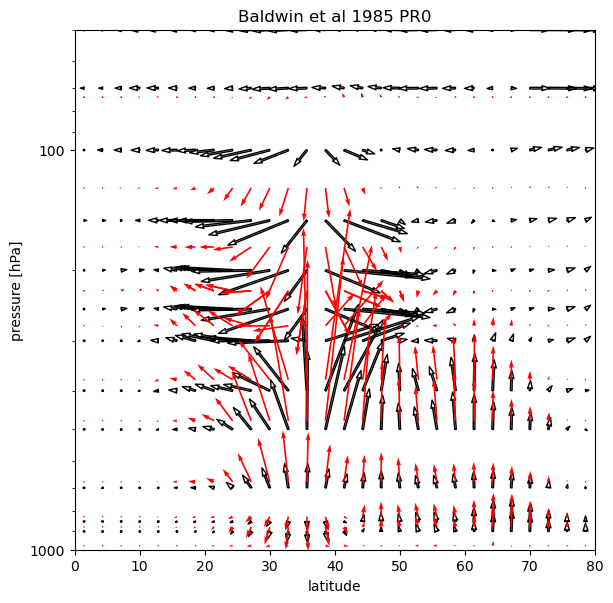

In [96]:
Fx = {}
Fy = {}
scale = "log"
# Baldwin et al 1985, Figure 6:
method = 'Baldwin'
quiv_args = {'angles':'uv','scale_units':'inches','linewidths':1,'edgecolors':'k','color':'none'}

# f1,f2,F_phi,F_p,div1,div2 = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1,divs=True)
lat = f1.sel(latitude=slice(80,0)).latitude
# pres = np.array([50,70,100,150,200,300,400,500,700,850])
pres = np.array([50,70,100,150,200,250,300,400,500,700,850,900,10000])

fig,ax = plt.subplots()
set_size(5.2,5.2,ax)
# Reference method
Fx[method],Fy[method] = Baldwin(F_phi.sel(latitude=lat,level=pres, method='nearest'),F_p.sel(latitude=lat,level=pres, method='nearest'),xlim=[0,80])
ax.quiver(lat,pres,Fx[method].mean(dim="time"),-Fy[method].mean(dim="time"),scale=3e8,**quiv_args)
# Jucker (2020) method
# print(f1)
_,_ = ac.PlotEPfluxArrows(f1.sel(latitude=lat, method='nearest').latitude,
                          f1.sel(level=pres, method='nearest').level,
                          f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                          -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                          fig,ax,xlim=[0,80],ylim=[1000,50],yscale=scale)
ax.get_children()[1].set_facecolor('r')
# if scale == 'linear':
#     ax.invert_yaxis()
plt.title(f'Baldwin et al 1985 PR{PR}')
ax.set_xlabel('latitude')
ax.set_ylabel('pressure [hPa]')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
# fig.savefig('figures/Baldwin85.{0}.pdf'.format(scale),bbox_inches='tight')

In [78]:
def Andrews(F_phi,F_p,pres='level',lat='latitude',xlim=[-90,90]):
	# Andrews et al JAS (1983)
	#  F_phi = a*cosphi*(-u'v' + ...)
	#  F_p   = a*cosphi*(-u'w' + ...)
	p0 =1013.25
	# note that they don't use H, or set H=1. That doesn't work.
	#  so we use the same H as all others here.
	H = 6.4e3
	z = -H*np.log(F_p[pres]/p0)
	# "To represent the vector F in a rectangular
	#  plot with phi and z as coordinates, Fphi and Fz
	#  are separately stretched in an obvious way."
	# They do not say what this obvious way is.
	# We give them the benefit of the doubt and do this correctly
	dx,dy = CorrectAspect([-90,90],z*1e-3)
	# What they do say is the following scaling:
	Fhat_phi = F_phi*F_p[pres]/p0
	Fhat_p   = -H*F_p/p0
	# note that this is equivalent to only rescaling F_p by -H/p
	# Fhat_phi = F_phi
	# Fhat_p   = -H*F_p/F_p[pres]
	return (dx*Fhat_phi).transpose(),(dy*Fhat_p).transpose(),z

(64, 20, 10000)


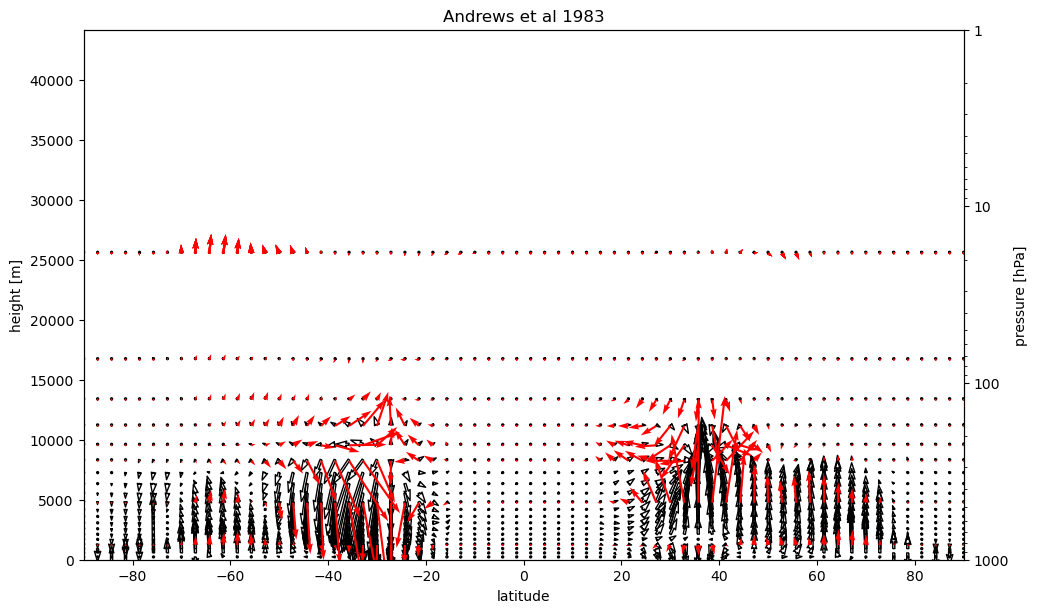

In [85]:
Fx = {}
Fy = {}
method = 'Andrews'
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = f1.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
Fx[method],Fy[method],z = Andrews(F_phi,F_p)
print(Fx[method].shape)
# _,_ = ac.PlotEPfluxArrows(
#     f1.latitude,
#     f1.level.sel(level=pres, method='nearest'),
#     f1.sel(level=pres, latitude=lat, method='nearest').mean(dim='time'),
#     f2.sel(level=pres, latitude=lat, method='nearest').mean(dim='time'),
#     fig, ax,
#     xlim=[0, 80], ylim=[1000, 50], yscale=scale
# )
if scale == 'log':
    ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e8,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                                  f1.level.sel(level=pres, method='nearest'),
                                  f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=6e14)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')
else:
    ax.quiver(lat,pres,Fx[method],Fy[method],scale=3e9,**quiv_args)
    # Jucker (2020) method
    _,_ = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,f1.sel(level=pres).level,f1.sel(latitude=lat,level=pres),f2.sel(latitude=lat,level=pres),fig,ax,xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=False,scale=1e15)
    ax.get_children()[1].set_facecolor('r')
plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


In [41]:
import h5py
import numpy as np
import xarray as xr
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# --- Step 1: 資料讀取 ---
def load_hdf5_variable(file_path, var, start_idx, end_idx):
    print(f"Reading variable '{var}' from {file_path}...")
    with h5py.File(file_path, "r") as ds:
        data = np.asarray(ds[var][start_idx:end_idx])
    print(f"Done reading '{var}'. Shape = {data.shape}")
    return data

# --- Step 2: 計算 EP flux ---
def compute_ep_flux(u, v, t, p, lat):
    print("Computing zonal mean pressure...")
    p_1d = p.mean(axis=(0, 2, 3))

    print("Running EP flux computation (Jucker method)...")
    ep1, ep2, div1, div2 = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)

    print("Wrapping results into xarray DataArrays...")
    time_len = u.shape[0]
    time_coord = np.arange(time_len)
    level_vals = np.round(p_1d / 100, 1)

    f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f1')
    f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f2')

    print("EP flux computation finished.\n")
    return f1, f2


In [42]:
# 設定 PR 實驗與資料區間
PR = 10
start_idx = 50000
end_idx = 70000
lat = np.linspace(90, -90, 64)

# 設定資料夾
base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}"

# 載入資料（含進度顯示）
u = load_hdf5_variable(f"{base_dir}/u/PR{PR}_500_20000day_6hourly_u.dat", "u", start_idx, end_idx)
v = load_hdf5_variable(f"{base_dir}/v/PR{PR}_500_20000day_6hourly_v.dat", "v", start_idx, end_idx)
t = load_hdf5_variable(f"{base_dir}/t/PR{PR}_500_20000day_6hourly_t.dat", "t", start_idx, end_idx)
p = load_hdf5_variable(f"{base_dir}/p/PR{PR}_500_20000day_6hourly_p.dat", "p", start_idx, end_idx)




Reading variable 'u' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/u/PR10_500_20000day_6hourly_u.dat...
Done reading 'u'. Shape = (20000, 20, 64, 128)
Reading variable 'v' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/v/PR10_500_20000day_6hourly_v.dat...
Done reading 'v'. Shape = (20000, 20, 64, 128)
Reading variable 't' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/t/PR10_500_20000day_6hourly_t.dat...
Done reading 't'. Shape = (20000, 20, 64, 128)
Reading variable 'p' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/p/PR10_500_20000day_6hourly_p.dat...
Done reading 'p'. Shape = (20000, 20, 64, 128)


In [43]:
# 計算 EP flux
f1, f2 = compute_ep_flux(u, v, t, p, lat)

Computing zonal mean pressure...
Running EP flux computation (Jucker method)...
Wrapping results into xarray DataArrays...
EP flux computation finished.



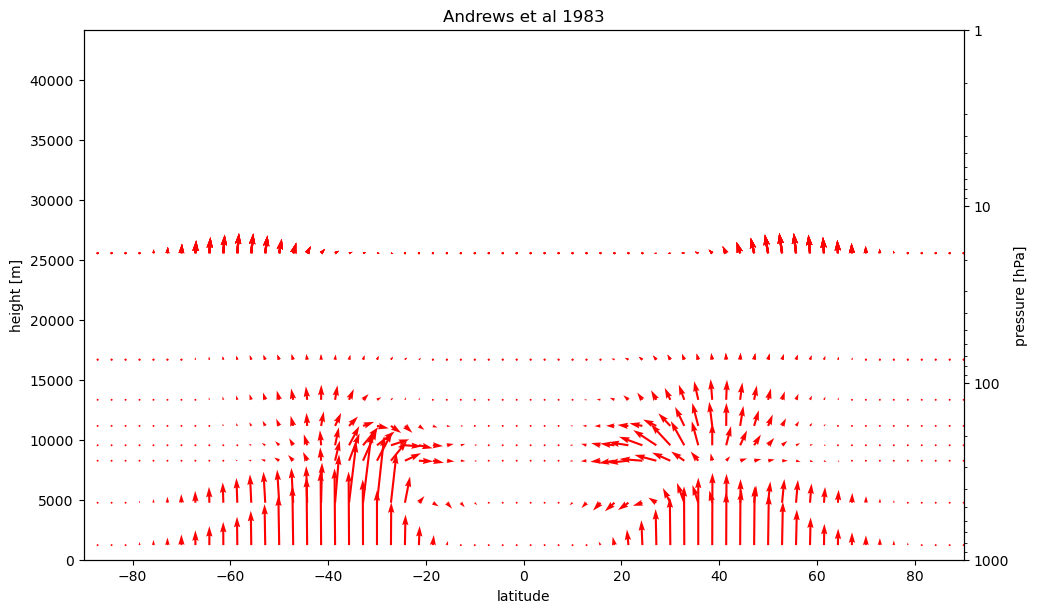

In [44]:
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
scale = "log"
if scale == 'log':
    # ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                                  f1.level.sel(level=pres, method='nearest'),
                                  -f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


In [68]:
PR = 0
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")

In [69]:
time_idx_array_positive

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

In [45]:
import h5py
import numpy as np
import xarray as xr
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

def load_hdf5_variable(file_path, var, start_idx, end_idx):
    print(f"Reading variable '{var}' from {file_path}...")
    with h5py.File(file_path, "r") as ds:
        data = np.asarray(ds[var][start_idx:end_idx])
    print(f"Done reading '{var}'. Shape = {data.shape}")
    return data

def compute_ep_flux(u, v, t, p, lat):
    p_1d = p.mean(axis=(0, 2, 3))

    print("Running EP flux computation (Jucker method)...")
    ep1, ep2, div1, div2 = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)

    print("Wrapping results into xarray DataArrays...")
    time_len = u.shape[0]
    time_coord = np.arange(time_len)
    level_vals = np.round(p_1d / 100, 1)

    f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f1')
    f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f2')

    print("EP flux computation finished.\n")
    return f1, f2

def process_PR_case(pr, lat, start_idx=50000, end_idx=70000):
    base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{pr}"
    print(f"\n========== Start processing PR = {pr} ==========")
    u = load_hdf5_variable(f"{base_dir}/u/PR{pr}_500_20000day_6hourly_u.dat", "u", start_idx, end_idx)
    v = load_hdf5_variable(f"{base_dir}/v/PR{pr}_500_20000day_6hourly_v.dat", "v", start_idx, end_idx)
    t = load_hdf5_variable(f"{base_dir}/t/PR{pr}_500_20000day_6hourly_t.dat", "t", start_idx, end_idx)
    p = load_hdf5_variable(f"{base_dir}/p/PR{pr}_500_20000day_6hourly_p.dat", "p", start_idx, end_idx)

    return compute_ep_flux(u, v, t, p, lat)

# 設定緯度與時間範圍
lat = np.linspace(90, -90, 64)
start_idx = 50000
end_idx = 70000

# PR=0 baseline
F_phi_base, F_p_base = process_PR_case(pr=0, lat=lat, start_idx=start_idx, end_idx=end_idx)

# 要比較的實驗 PR 值
PR_list = range(10, 20, 10)

# 儲存差異結果
diffs = {}

for pr in PR_list:
    F_phi_cmp, F_p_cmp = process_PR_case(pr=pr, lat=lat, start_idx=start_idx, end_idx=end_idx)

    # 內插至 PR=0 的 pressure level，以避免 shape mismatch
    F_phi_cmp_interp = F_phi_cmp.interp(level=F_phi_base.level, method="nearest")
    F_p_cmp_interp   = F_p_cmp.interp(level=F_p_base.level,   method="nearest")

    diff_phi = F_phi_cmp_interp - F_phi_base
    diff_p   = F_p_cmp_interp   - F_p_base

    diffs[pr] = (diff_phi, diff_p)

    print(f"✓ PR={pr} vs PR=0 difference computed.\n{'-'*40}")



========== Start processing PR = 0 ==========
Reading variable 'u' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat...
Done reading 'u'. Shape = (20000, 20, 64, 128)
Reading variable 'v' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/PR0_500_20000day_6hourly_v.dat...
Done reading 'v'. Shape = (20000, 20, 64, 128)
Reading variable 't' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/PR0_500_20000day_6hourly_t.dat...
Done reading 't'. Shape = (20000, 20, 64, 128)
Reading variable 'p' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/p/PR0_500_20000day_6hourly_p.dat...
Done reading 'p'. Shape = (20000, 20, 64, 128)
Running EP flux computation (Jucker method)...
Wrapping results into xarray DataArrays...
EP flux

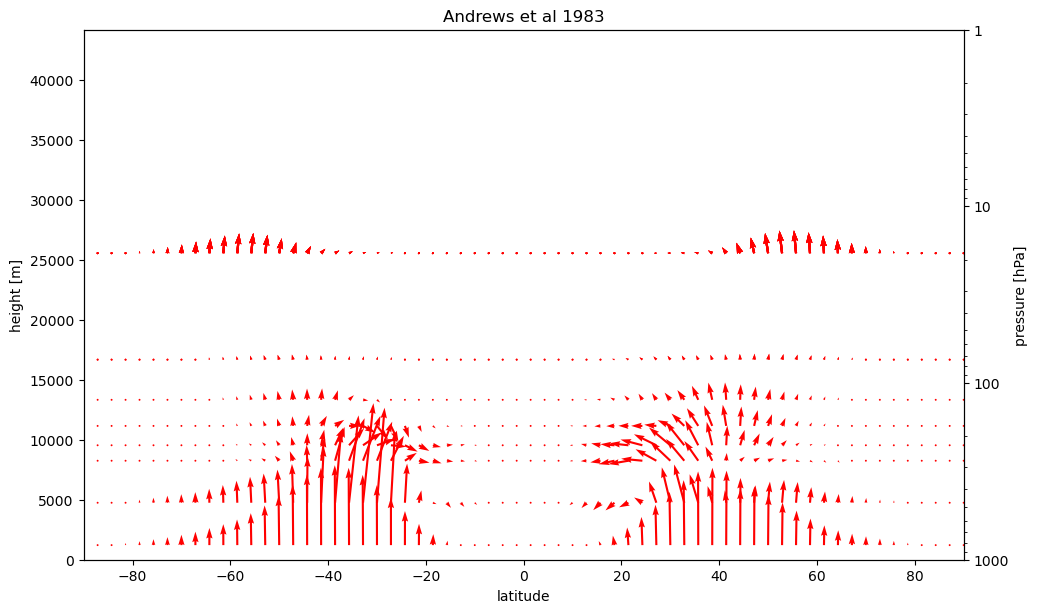

In [65]:
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi_base.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
scale = "log"
if scale == 'log':
    # ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(F_phi_cmp_interp.sel(latitude=lat).latitude,
                                  F_phi_cmp_interp.level.sel(level=pres, method='nearest'),
                                  -F_phi_cmp_interp.sel(latitude=lat,level=pres, method='nearest').mean(dim='time') - (-F_phi_base.sel(latitude=lat,level=pres, method='nearest').mean(dim='time')),
                                  -F_p_cmp_interp.sel(latitude=lat,level=pres, method='nearest').mean(dim='time') - (-F_p_base.sel(latitude=lat,level=pres, method='nearest').mean(dim='time')),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


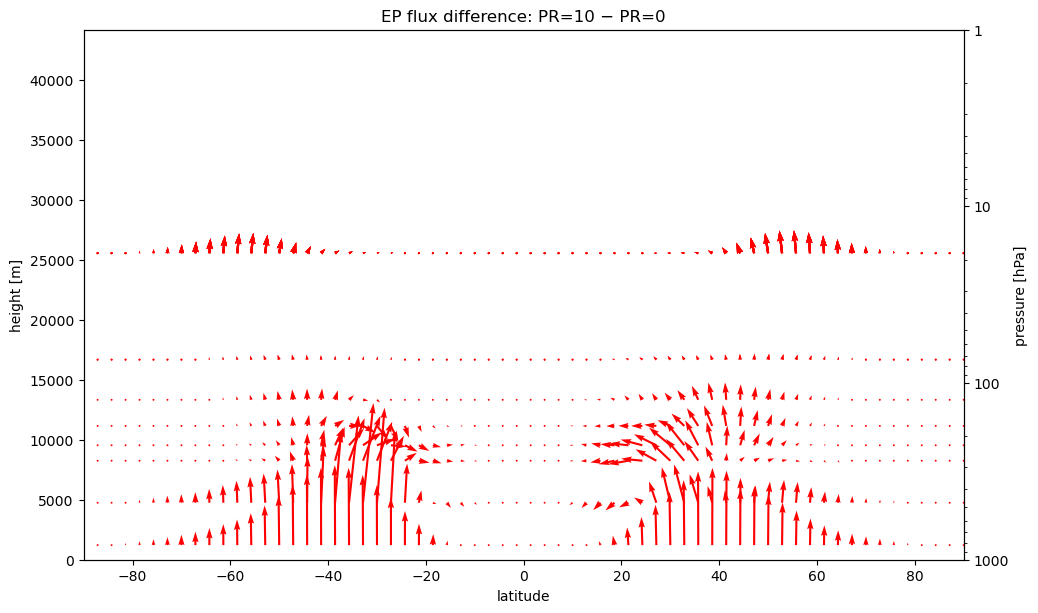

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pres = np.array([850, 500, 300, 200, 150, 100, 70, 50, 30, 20, 10, 7, 5, 2])[::-1]
lat = diffs[10][0].latitude  # 或 f1.latitude

fig, ax = plt.subplots()
set_size(8.8, 5.3, ax)
scale = "log"

# 取出差值資料
ep1_diff = diffs[10][0].sel(latitude=lat, level=pres, method='nearest').mean(dim='time')
ep2_diff = diffs[10][1].sel(latitude=lat, level=pres, method='nearest').mean(dim='time')

# 確保維度對齊（展平）
yy, xx = xr.broadcast(ep1_diff.level, ep1_diff.latitude)




if scale == 'log':
    _, _, axp = ac.PlotEPfluxArrows(
        xx.values, yy.values,
        -ep1_diff.values, -ep2_diff.values,
        fig, ax,
        xlim=[-90, 90],
        ylim=[1000, 1],
        yscale='log',
        newax=True,
        scale=3e15
    )
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 6.4e3 * np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('EP flux difference: PR=10 − PR=0')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())


## Test PC1 > std and < std time index 

In [ ]:
import numpy as np
import xarray as xr
import h5py

# Constants
lat = np.linspace(90, -90, 64)
lags_5_20 = range(15 * 4, 15 * 4+1, 1)  # lags 15–25 days
lags_30_60 = range(90 * 4, 90 * 4+1, 1)  # lags 90–100 days
PR_list = [0, 10]

# Load all variables only once per PR
def load_all_variables(pr):
    base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{pr}"
    def load_var(var):
        with h5py.File(f"{base_dir}/{var}/PR{pr}_500_20000day_6hourly_{var}.dat", "r") as ds:
            return np.asarray(ds[var][:])
    return {
        "u": load_var("u"),
        "v": load_var("v"),
        "t": load_var("t"),
        "p": load_var("p"),
    }

# Wrapper to compute EP flux using provided arrays
def compute_ep_flux(u, v, t, p, lat):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
    import aostools_functions as ac
    p_1d = p.mean(axis=(0, 2, 3))
    ep1, ep2  = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)
    level_vals = np.round(p_1d / 100, 1)
    return xr.DataArray(ep1, dims=["time", "level", "latitude"],
                        coords={"time": np.arange(u.shape[0]), "level": level_vals, "latitude": lat}), \
           xr.DataArray(ep2, dims=["time", "level", "latitude"],
                        coords={"time": np.arange(u.shape[0]), "level": level_vals, "latitude": lat})

# Composite EP flux for a specific PR
def composite_ep_flux(data, time_idx_array, lags):
    f1_all, f2_all = [], []
    u, v, t, p = data["u"], data["v"], data["t"], data["p"]
    for lag in lags:
        valid_idx = time_idx_array + lag
        valid_idx = valid_idx[(valid_idx >= 0) & (valid_idx < u.shape[0])]
        if len(valid_idx) == 0:
            continue
        f1, f2 = compute_ep_flux(u[valid_idx], v[valid_idx], t[valid_idx], p[valid_idx], lat)
        f1_all.append(f1.mean("time"))
        f2_all.append(f2.mean("time"))
    return xr.concat(f1_all, dim="lag").mean("lag"), xr.concat(f2_all, dim="lag").mean("lag")

# Storage
same_pr_ep_diff = {}
final_diff_vs_pr0 = {}

for pr in PR_list:
    print(f"Loading data for PR={pr}...")
    data = load_all_variables(pr)

    time_idx_pos = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{pr}.npy")
    time_idx_neg = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{pr}.npy")

    print(f"--> Computing EP+ composite for PR={pr}")
    ep1_pos, ep2_pos         = composite_ep_flux(data, time_idx_pos, lags_5_20)
    ep1_far_pos, ep2_far_pos = composite_ep_flux(data, time_idx_pos, lags_30_60)
    
    # interpolate to ep1_far_pos.level
    ep1_pos_interp = ep1_pos.interp(level=ep1_far_pos.level, method="nearest")
    ep2_pos_interp = ep2_pos.interp(level=ep2_far_pos.level, method="nearest")
    
    EP_plus   = ep1_pos_interp - ep1_far_pos
    EP_plus_p = ep2_pos_interp - ep2_far_pos
    print(ep1_pos_interp.shape, ep1_far_pos.shape, EP_plus.shape)

    print(f"--> Computing EP- composite for PR={pr}")
    ep1_neg, ep2_neg         = composite_ep_flux(data, time_idx_neg, lags_5_20)
    ep1_far_neg, ep2_far_neg = composite_ep_flux(data, time_idx_neg, lags_30_60)

    # interpolate to ep1_far_pos.level
    ep1_neg_interp = ep1_neg.interp(level=ep1_far_neg.level, method="nearest")
    ep2_neg_interp = ep2_neg.interp(level=ep2_far_neg.level, method="nearest")
    
    EP_minus   = ep1_neg_interp - ep1_far_neg
    EP_minus_p = ep2_neg_interp - ep2_far_neg
 
    # interpolate to ep1_far_pos.level
    EP_plus_interp   = EP_plus.interp(level=EP_minus.level, method="nearest")
    EP_plus_p_interp = EP_plus_p.interp(level=EP_minus_p.level, method="nearest")
    
    diff_phi = EP_plus_interp - EP_minus
    diff_p   = EP_plus_p_interp - EP_minus_p
    print(diff_phi.shape, EP_plus_interp.shape, EP_minus.shape)
    same_pr_ep_diff[pr] = (diff_phi, diff_p)

    # === Save EP flux diff results ===
    save_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff.nc"
    print(f"\nSaving EP flux diff to {save_path}...")
    
    # 將所有 PR 的資料整理進 Dataset
    ds_out = xr.Dataset()
    for pr in same_pr_ep_diff:
        ds_out[f"EP_phi_diff_PR{pr}"] = same_pr_ep_diff[pr][0]
        ds_out[f"EP_p_diff_PR{pr}"]   = same_pr_ep_diff[pr][1]
    
    # 儲存為 NetCDF
    ds_out.to_netcdf(save_path)
    print("✓ Save complete.")




Loading data for PR=0...
--> Computing EP+ composite for PR=0


In [105]:
# # Difference from PR=0
# for pr in PR_list:
#     if pr == 0:
#         continue
#     diff_vs_pr0_phi = same_pr_ep_diff[pr][0].interp_like(same_pr_ep_diff[0][0]) - same_pr_ep_diff[0][0]
#     diff_vs_pr0_p   = same_pr_ep_diff[pr][1].interp_like(same_pr_ep_diff[0][1]) - same_pr_ep_diff[0][1]
#     final_diff_vs_pr0[pr] = (diff_vs_pr0_phi, diff_vs_pr0_p)

In [106]:
# # Read vars
# ds = xr.open_dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff.nc")
# diff_phi_pr10 = ds["EP_phi_diff_PR10"]
# diff_p_pr10   = ds["EP_p_diff_PR10"]



In [114]:
# final_diff_vs_pr0

{10: (<xarray.DataArray (level: 20, latitude: 64)>
  array([[-3.8516947 , -3.23973083, -2.6589179 , ..., -0.99085236,
          -0.45372963,  0.06197524],
         [-1.93421799, -1.50063115, -1.1260221 , ...,  0.12778568,
           0.20422363,  0.09035873],
         [-1.30833197, -1.09333616, -0.96419317, ...,  0.23661375,
          -0.01366401, -0.48415327],
         ...,
         [-0.12254799, -0.15582364, -0.28727569, ...,  0.4062733 ,
           0.11694629, -0.45112983],
         [-0.08480896, -0.13370002, -0.28826914, ...,  0.42214258,
           0.12026978, -0.5048875 ],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]])
  Coordinates:
    * latitude  (latitude) float64 90.0 87.14 84.29 81.43 ... -84.29 -87.14 -90.0
    * level     (level) float32 18.4 73.7 124.4 174.7 ... 826.3 876.4 926.5 976.6,
  <xarray.DataArray (level: 20, latitude: 64)>
  array([[-2.37349350e-05, -5.24656825e-05, -7.94330759e-05, ...,
           3.0293

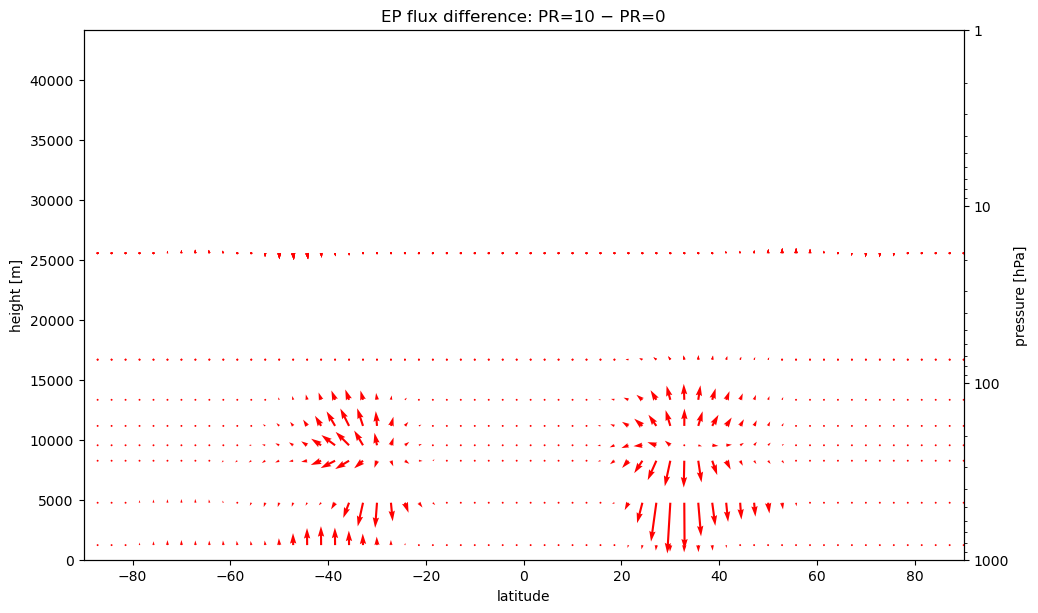

In [115]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

pres = np.array([850, 500, 300, 200, 150, 100, 70, 50, 30, 20, 10, 7, 5, 2])[::-1]
lat = same_pr_ep_diff[10][0].latitude  # 或 f1.latitude

fig, ax = plt.subplots()
set_size(8.8, 5.3, ax)
scale = "log"

# 取出差值資料
ep1_diff = same_pr_ep_diff[10][0].sel(latitude=lat, level=pres, method='nearest')
ep2_diff = same_pr_ep_diff[10][1].sel(latitude=lat, level=pres, method='nearest')
# 確保維度對齊（展平）
yy, xx = xr.broadcast(ep1_diff.level, ep1_diff.latitude)

if scale == 'log':
    _, _, axp = ac.PlotEPfluxArrows(
        xx.values, yy.values,
        -ep1_diff.values, -ep2_diff.values,
        fig, ax,
        xlim=[-90, 90],
        ylim=[1000, 1],
        yscale='log',
        newax=True,
        scale=3e15
    )
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 6.4e3 * np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('EP flux difference: PR=10 − PR=0')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())


In [43]:
ep1_diff.values.min()

-1.1920928999487046e-07

In [49]:
ep2_diff.values.max()

2.220446049250313e-16

## Jucker EP flux batch

In [72]:
PR

50

In [102]:
import numpy as np
import xarray as xr
import h5py
import sys
import os
from tqdm import tqdm

# 匯入 Jucker 的工具
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# === 設定參數 ===
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
chunk_size = 1000
a0 = 6376.0e3
lat_vals = np.linspace(90, -90, 64)
cosphi = np.cos(np.deg2rad(lat_vals))

# === 建立空間儲存區 ===
all_ep1 = []
all_ep2 = []
all_p_1d = []

# === 分段處理 ===
for start_idx in tqdm(range(0, 78000, chunk_size)):
    end_idx = min(start_idx + chunk_size, 78000)
    print(f"Processing: {start_idx} ~ {end_idx}")

    # 計算平均壓力 (ps、p為4D: time, level, lat, lon)
    p_1d = p[start_idx:end_idx].mean(axis=(0, 2, 3))

    # 計算 EP flux
    ep1, ep2 = ac.ComputeEPfluxDiv(lat_vals, p_1d / 100,
                                   u[start_idx:end_idx],
                                   v[start_idx:end_idx],
                                   t[start_idx:end_idx])
    
    all_ep1.append(ep1)  # shape: (time_chunk, level, lat)
    all_ep2.append(ep2)
    all_p_1d.append(p_1d)

# === 合併所有時間段 ===
ep1_all = np.concatenate(all_ep1, axis=0)
ep2_all = np.concatenate(all_ep2, axis=0)
time_len = ep1_all.shape[0]
time_coord = np.arange(time_len)
level_coord = np.mean(np.stack(all_p_1d), axis=0) / 100  # hPa

# === 存成 xarray ===
f1 = xr.DataArray(ep1_all, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": level_coord,
                          "latitude": lat_vals},
                  name="f1")

f2 = xr.DataArray(ep2_all, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": level_coord,
                          "latitude": lat_vals},
                  name="f2")







  0%|                                                    | 0/78 [00:00<?, ?it/s]

Processing: 0 ~ 1000


  1%|▌                                           | 1/78 [00:12<16:10, 12.60s/it]

Processing: 1000 ~ 2000


  3%|█▏                                          | 2/78 [00:18<10:42,  8.45s/it]

...

 97%|█████████████████████████████████████████▉ | 76/78 [04:19<00:04,  2.26s/it]

Processing: 76000 ~ 77000


 99%|██████████████████████████████████████████▍| 77/78 [04:21<00:02,  2.19s/it]

Processing: 77000 ~ 78000


100%|███████████████████████████████████████████| 78/78 [04:23<00:00,  3.38s/it]


In [103]:
# 建立 Dataset，f1, f2 已經是 DataArray，不需再指定 shape
ds_out = xr.Dataset({
    "f1": f1,
    "f2": f2
})

# 儲存為 .nc 檔案（建議使用 .nc 而非 .h5，與 xarray 相容性較佳）
save_path = os.path.join(save_dir, f"ep_flux_PR{PR}.h5")
ds_out.to_netcdf(save_path)
print(f"✓ Saved to {save_path}")

✓ Saved to /data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/ep_flux_PR50.h5


# Check $N^2$

In [74]:
# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

In [80]:
N_square_all = np.zeros((6, 78000, 20, 64))
i = 0
g = 9.81
# Read zonal mean variables
for PR in range(0, 60, 10):
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    # v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
    # EMF_all              = Read_var_simple("EMF", PR)
    
    # Calculate N squared
    dthetadz_all = dtheta_all / dz_all
    N_square_all[i] = g / theta_zonal_mean_all * dthetadz_all
    i += 1

KeyboardInterrupt: 

In [77]:
N_square_all.shape

(6, 78000, 20, 64)

In [146]:
def plot_contourf_near0_fixcolorbar_fig2_3(X, Y ,var_near0, axs, cbar_lim, shading_levels = 9, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        # cbar = plt.colorbar(cs, spacing="proportional")
        # cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # axs.title("$N^2$ difference between L = Dry", fontsize=14)
        # plt.xlabel("Latitude")
        # ax.set_ylabel("Sigma")
        axs.set_ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

L = Dry, N^2.min(): -6.124469657428794e-05
L = Dry, N^2.max(): 0.0006177863715981209


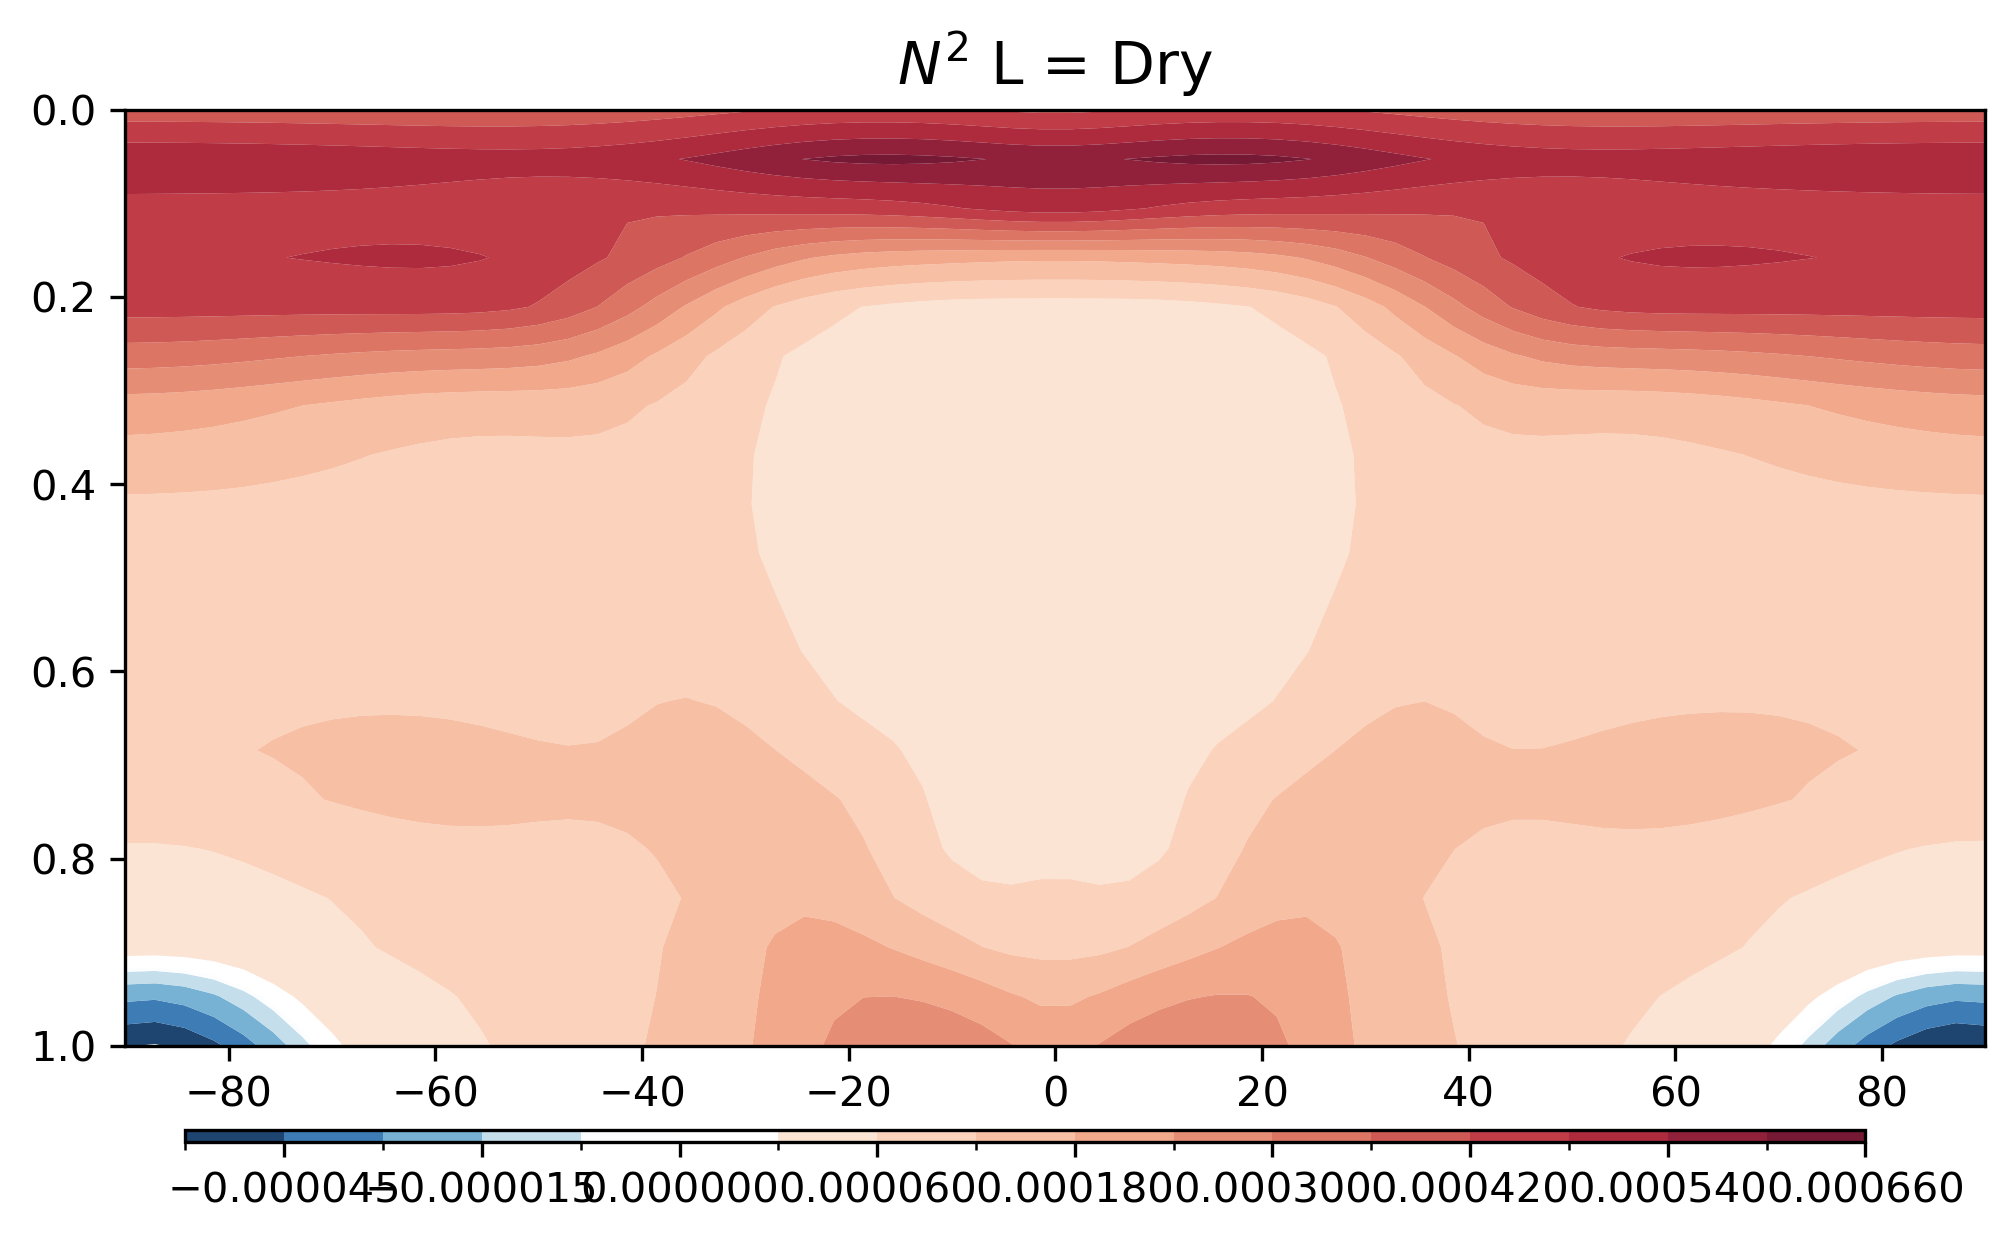

In [174]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(1, figsize=(8,4), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

_, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
    y, sigma, N_square_all[0,5000*4:].mean(axis=0), ax, 
    cbar_lim=[-5E-5, 6.1E-4],
    my_cmap='RdBu_r'
)
plt.title("$N^2$ L = Dry", fontsize=14)
cs_for_colorbar = cs  # store the last cs

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')
print("L = Dry, N^2.min():", N_square_all[0,5000*4:].mean(axis=0).min())
print("L = Dry, N^2.max():", N_square_all[0,5000*4:].mean(axis=0).max())


-1.9842596768561763e-05
4.682385210088918e-05
-5.008153503806742e-05
7.510465274876275e-05
-8.391108011026761e-05
9.540901275533246e-05
-0.00010323475817430554
0.0001182973797827431
-0.00012576956493570132
0.00013776118802514737


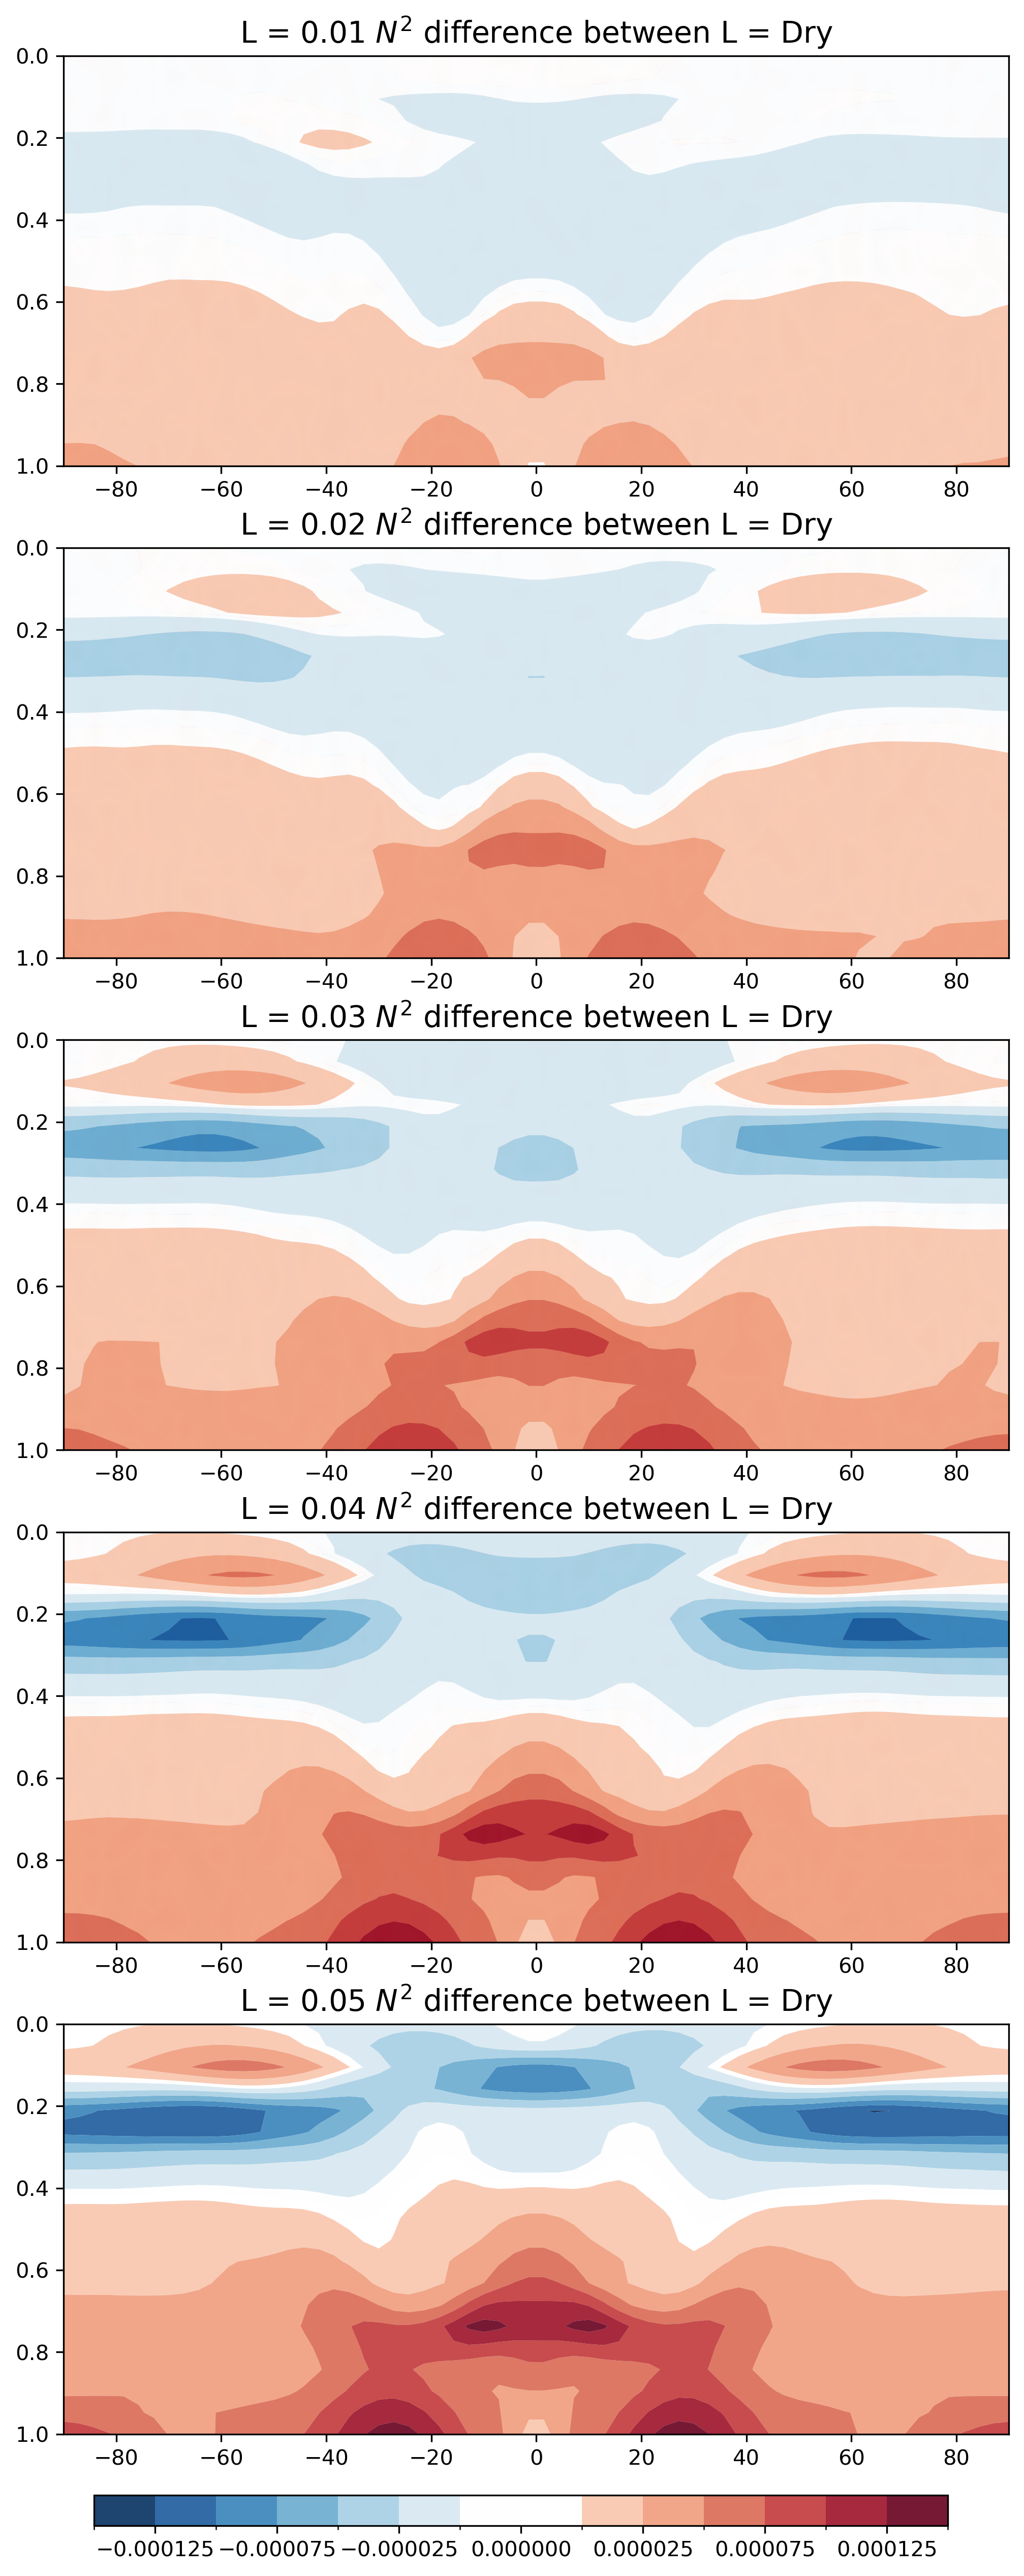

In [175]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(5, figsize=(8,20), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

for i in range(5):
    N_square_diff = N_square_all[i+1,5000*4:].mean(axis=0) - N_square_all[0,5000*4:].mean(axis=0)
    _, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
        y, sigma, N_square_diff, ax[i], 
        cbar_lim=[-1.5E-4, 1.5E-4],
        my_cmap='RdBu_r'
    )
    ax[i].set_title(f"L = {(i+1)*0.01} $N^2$ difference between L = Dry", fontsize=14)
    cs_for_colorbar = cs  # store the last cs
    print(N_square_diff.min())
    print(N_square_diff.max())
    

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')


In [44]:
# Constant
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90,90,64)))
g  = 9.81

In [52]:
ehf.shape

(400, 20, 64, 128)

In [59]:
# EP flux j and k component
F_j =  emf.mean(axis=(0,3)) # np.mean(EMF, axis=(0,3))
F_k = (f0[np.newaxis, np.newaxis, :] * ehf.mean(axis=3) / N_square_test_all).mean(axis=0)

In [60]:
F_j.shape

(20, 64)

(1.0, 0.0)

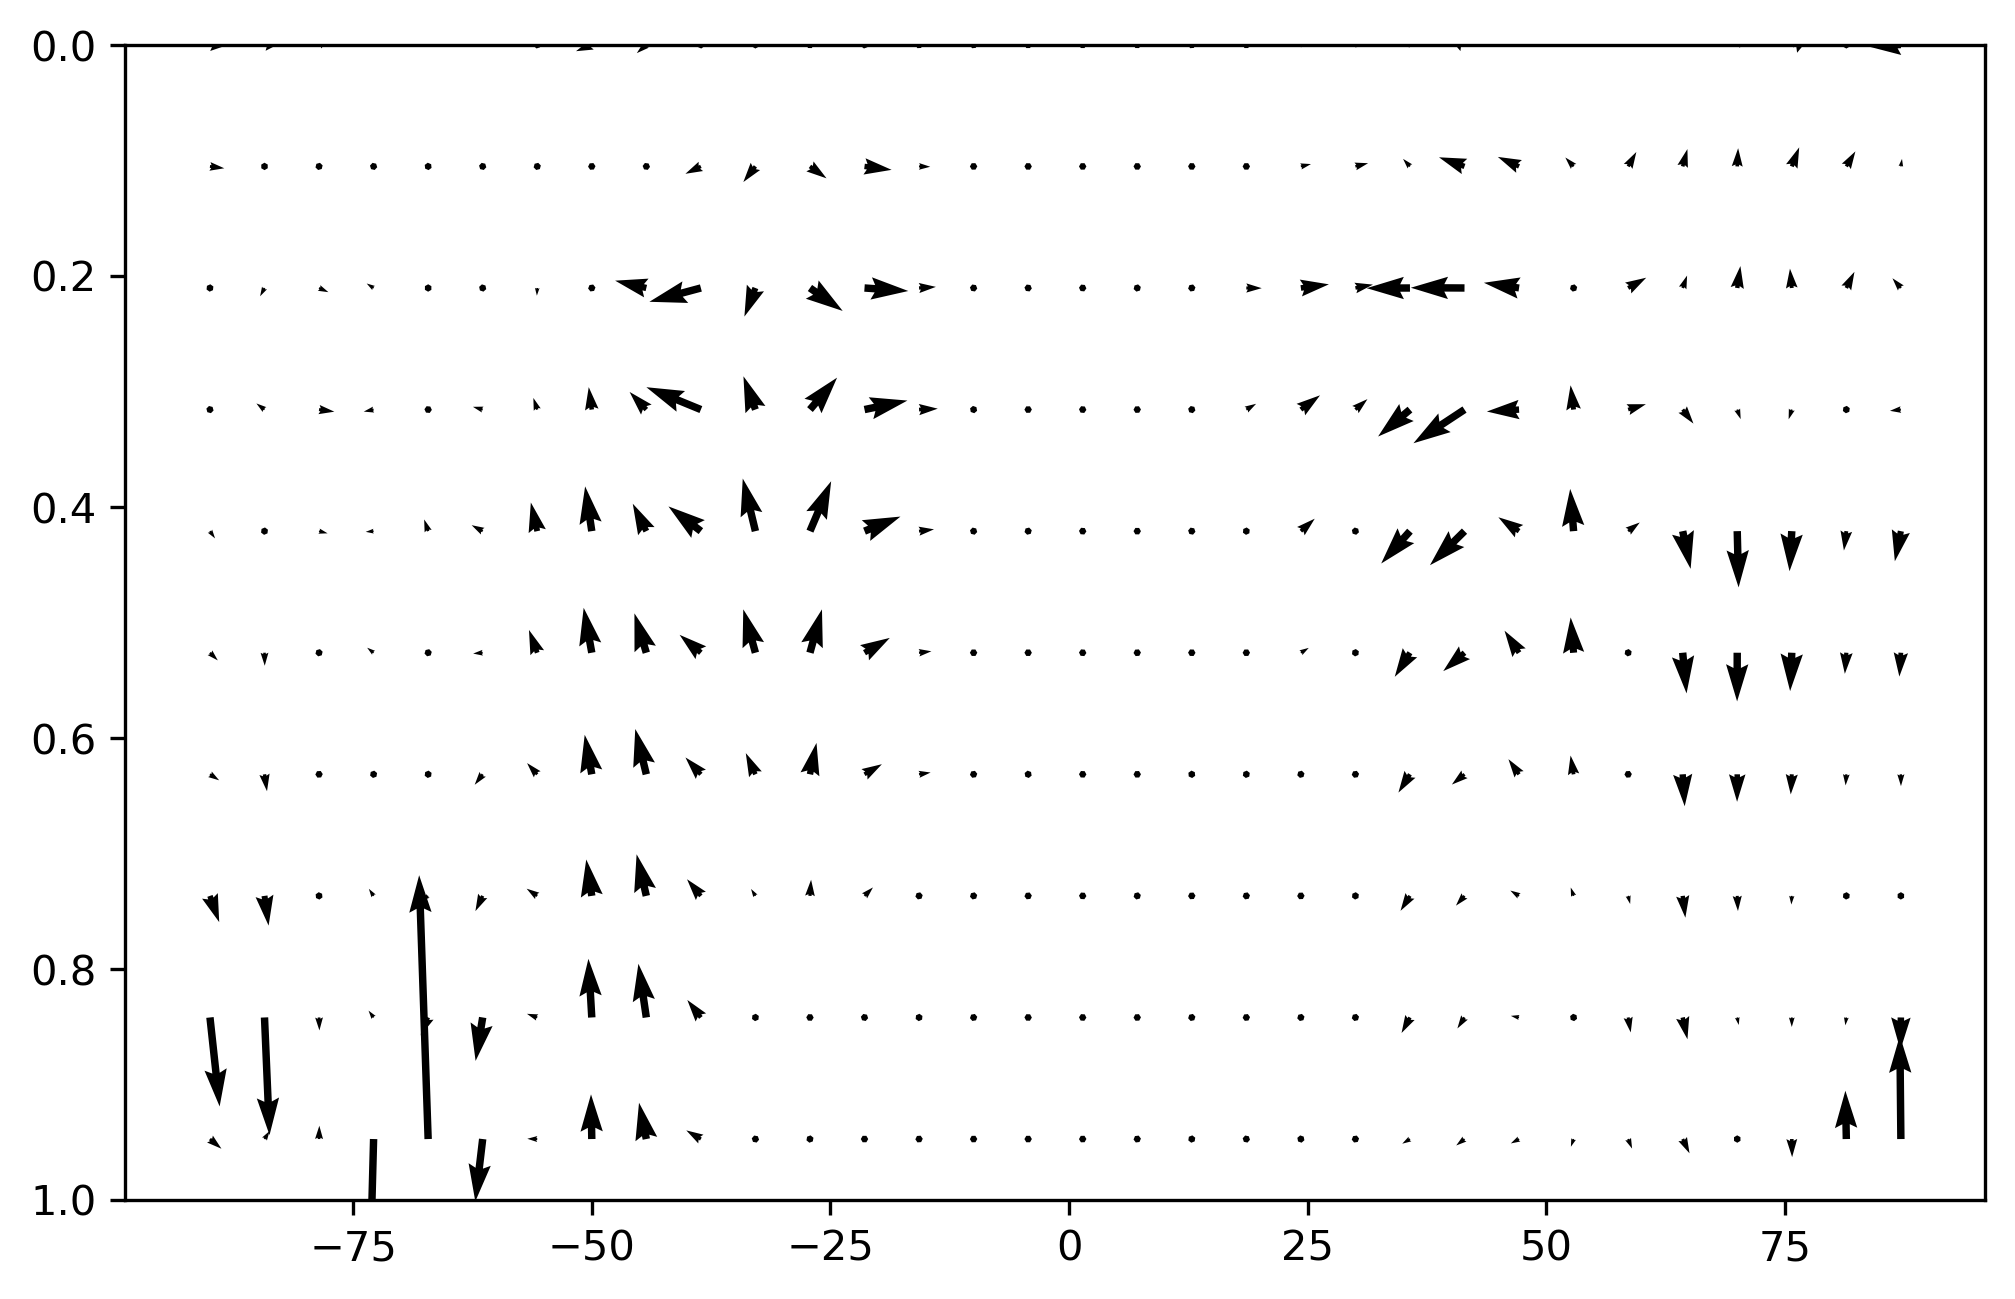

In [61]:
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=300)
y = np.linspace(-90,90,64)
z = np.linspace(0,1,20)
yy, zz = np.meshgrid(y,z)
wind_plt = ax.quiver(yy[::2, ::2], zz[::2, ::2], -F_j[::2, ::2], F_k[::2, ::2],
          color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)
plt.ylim([1,0])

# Cal EP flux again 05/22

In [81]:
PR = 0
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")

In [254]:
time_idx_array_positive[:]

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

## EMF and EHF

In [12]:
start_idx = 5000
end_idx   = 7000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
emf_mean, ehf_mean = adiag.run_emf_ehf()
emf_mean.shape

EMF and EHF progress:
[########################################] | 100% Completed | 312.58 ms
[########################################] | 100% Completed | 2.43 sms


(2000, 20, 64, 128)

Text(0.5, 1.0, "EHF ($\\overline{v'b'}$)")

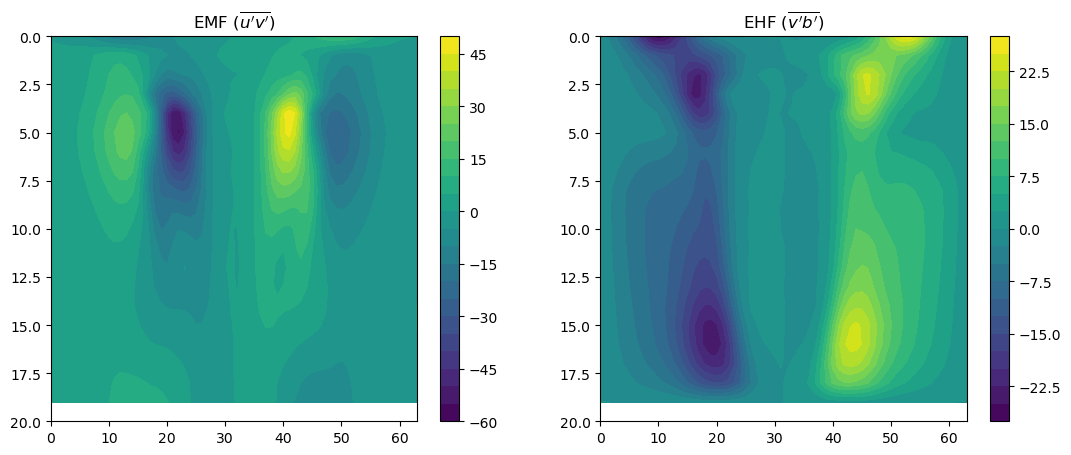

In [13]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(emf_mean.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"EMF ($\overline{u'v'}$)")

cs2 = ax2.contourf(ehf_mean.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title("EHF ($\overline{v'b'}$)")



## $\theta$ and $\partial \theta$

In [172]:
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
theta = adiag.cal_theta()  
dtheta, dtheta_zm = adiag.dtheta() 


Computing ∂θ/∂z ...


In [173]:
theta.shape

(2000, 20, 64, 128)

Text(0.5, 1.0, '$\\partial \\theta$')

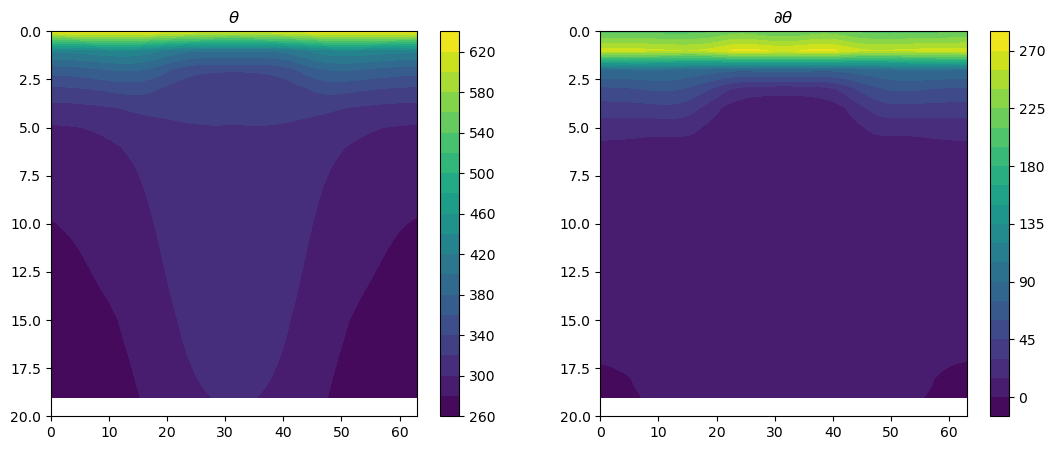

In [174]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(theta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"$\theta$")

cs2 = ax2.contourf(dtheta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial \theta$")



In [29]:
# dx_along_axis
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
theta = adiag.cal_theta()  
print(theta.shape)
dtheta, dtheta_zm = adiag.dx_along_axis(theta, axis=1) 


(2000, 20, 64, 128)
Computing ∂(x)/∂(axis 1) ...


Text(0.5, 1.0, '$\\partial \\theta$')

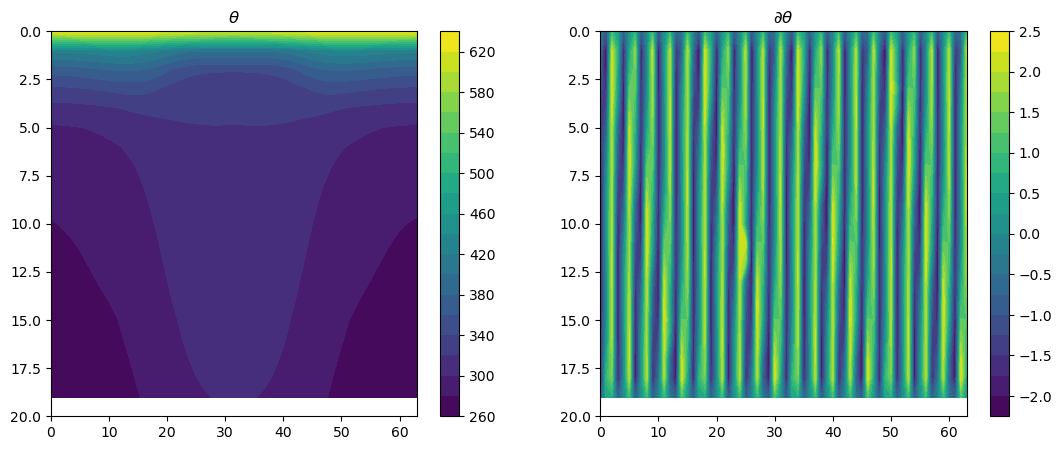

In [30]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(theta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"$\theta$")

cs2 = ax2.contourf(dtheta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial \theta$")



In [25]:
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
dz, dz_zm = adiag.dx_along_axis(z[2000:4000], axis=1) 

Computing ∂(x)/∂(axis 1) ...


Text(0.5, 1.0, '$\\partial z$')

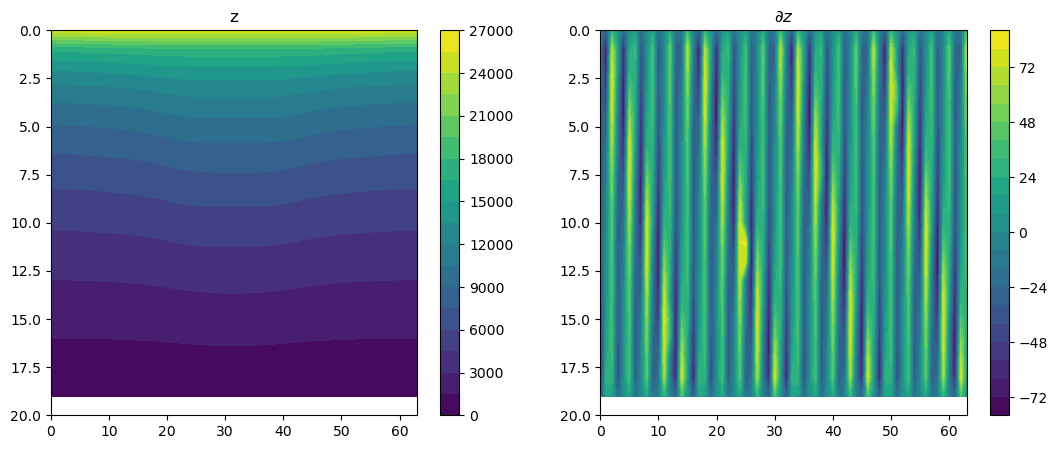

In [26]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(z.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"z")

cs2 = ax2.contourf(dz.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial z$")



## Cal N2

In [84]:
start_idx = 2000
end_idx   = 4000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
N2 = adiag.Cal_N_square()

[ 1844.2168  7376.867  12448.458  17485.873  22512.385  27533.992
 32552.914  37570.32   42586.7    47602.445  52617.613  57632.42
 62646.91   67661.28   72675.39   77689.53   82703.414  87717.27
 92730.89   97744.66  ]
[[[-5.02824461e-02 -5.03041238e-02 -5.03288471e-02 ... -5.10100481e-02
   -5.11001330e-02 -5.11529609e-02]
  [-2.45193297e-02 -2.45326493e-02 -2.45503611e-02 ... -2.49461526e-02
   -2.49912403e-02 -2.50124711e-02]
  [-8.80533993e-03 -8.82150806e-03 -8.84711159e-03 ... -9.09603946e-03
   -9.10124143e-03 -9.10127000e-03]
  ...
  [-5.31402302e-05 -5.77879019e-05 -6.67609644e-05 ... -6.26373184e-05
   -5.47464500e-05 -5.12516130e-05]
  [ 4.71300099e-05  3.84464663e-05  2.41204632e-05 ...  2.77576894e-05
    3.69420619e-05  3.92228234e-05]
  [ 1.74618771e-04  1.60601065e-04  1.38665435e-04 ...  1.41692936e-04
    1.53044162e-04  1.54109188e-04]]]


In [77]:
print(N2.min(), N2.max())

-0.054796669637423495 0.0001746187713322982


In [78]:
f0_array = adiag.f0()[np.newaxis, np.newaxis, :, np.newaxis]
ratio = f0_array / N2

print("N² min/max:", np.nanmin(N2), np.nanmax(N2))
print("f₀/N² min/max/mean:", np.nanmin(ratio), np.nanmax(ratio), np.nanmean(ratio))

ValueError: operands could not be broadcast together with shapes (1,1,64,1) (1,20,64) 

AxisError: axis 3 is out of bounds for array of dimension 3

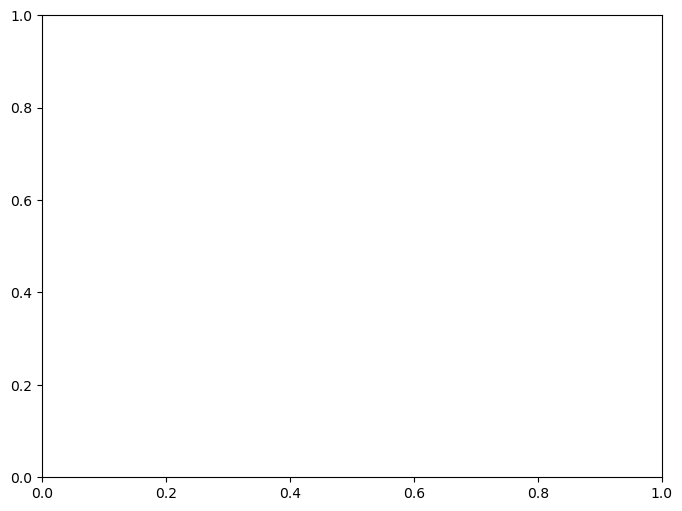

In [79]:
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf(N2.mean(axis=(0,3)), levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title("$N^2$")

In [85]:
N2.shape

(1, 20, 64)

Text(0.5, 1.0, '$f0/N^2$')

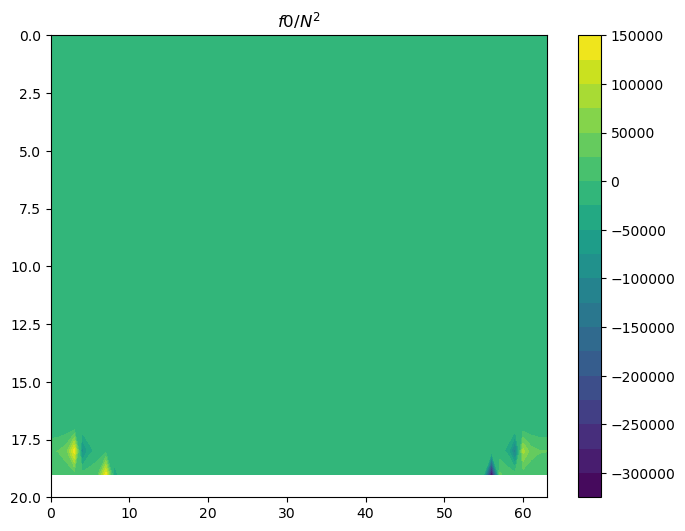

In [88]:
lat = adiag.lat
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf(1/(N2).mean(axis=(0)) , levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title("$f0/N^2$")

## $\partial \theta \over \partial p$

In [1132]:
start_idx = 2000
end_idx   = 4000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
dtheta_dp = adiag.dtheta_dp_columnwise()

Text(0.5, 1.0, '$\\frac{\\partial \\theta}{\\partial p}$')

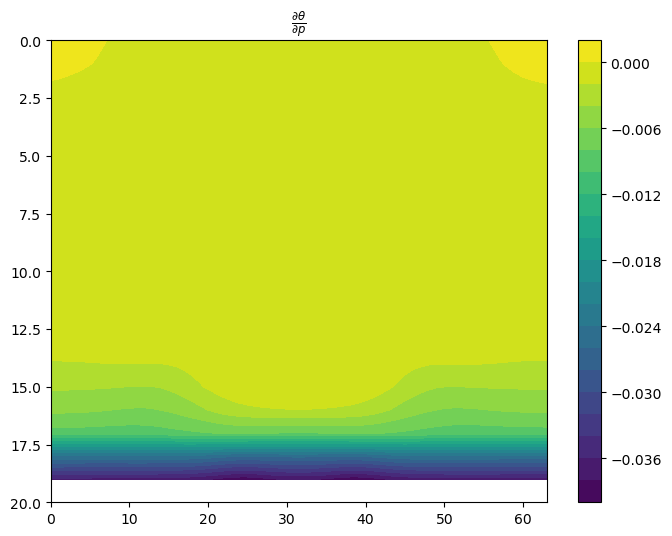

In [1149]:
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf((dtheta_dp).mean(axis=(0,3)) , levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title(r"$\frac{\partial \theta}{\partial p}$")


# EP flux 

In [123]:
start_idx = 0
end_idx   = 78000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
Fj, Fk  = adiag.ep_flux()


EMF and EHF progress:
[########################################] | 100% Completed | 313.20 ms
[########################################] | 100% Completed | 312.49 ms
Fj.shape: (2000, 20, 64)
Fk.shape: (2000, 20, 64)


In [126]:
print(Fj.min(), Fj.max())
print(Fk.min(), Fk.max())



-315.76587 292.93887
-41.05854993067743 17.864002949268006


In [127]:
Fk.shape

(2000, 20, 64)

In [128]:
Fj_mean = Fj.mean(axis=(0))  # shape: (z, y)
Fk_mean = Fk.mean(axis=(0))  # shape: (z, y)
Fk_mean.shape

(20, 64)

In [129]:
print(Fj_mean.min(), Fj_mean.max())
print(Fk_mean.min(), Fk_mean.max())

-87.15979 80.705765
-5.252750118938059 0.6793592036444148


Text(0.5, 1.0, 'Fk')

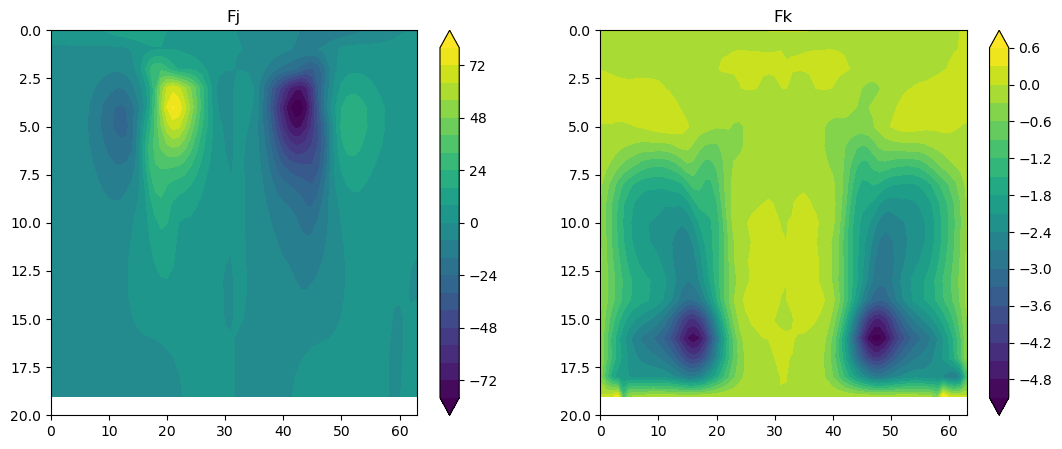

In [133]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(Fj_mean, levels=21, extend="both")
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"Fj")

cs2 = ax2.contourf(Fk_mean, levels=21, extend="both")
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"Fk")



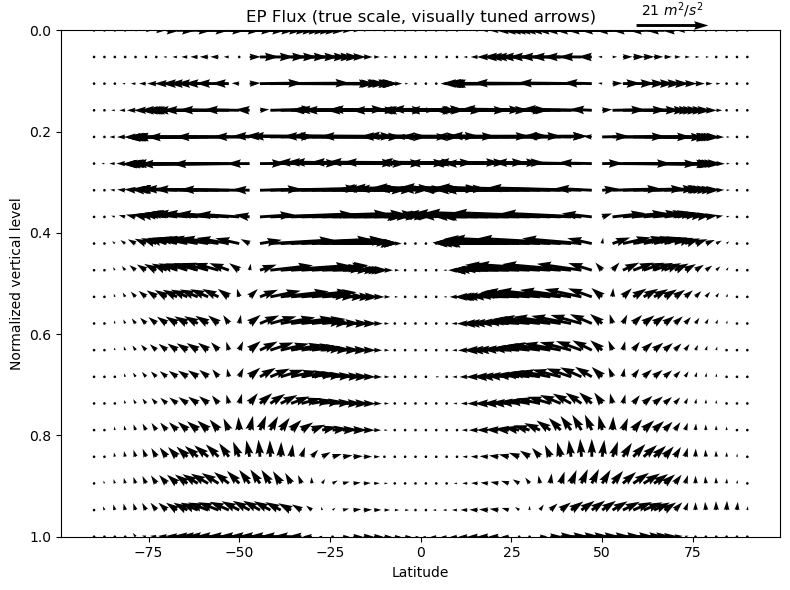

In [132]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj_mean**2 + Fk_mean**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 10 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)

fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_mean[::, ::], -Fk_mean[::, ::],
    color="black", width=4e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_ylim([1, 0])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


# Batch calculate EP flux and Save

In [175]:
import os
import h5py
import numpy as np

# 設定儲存資料夾與 PR 名稱
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
# PR = 50  # <-- 請依你的需求設定
batch_size = 10000
n_total = 78000

# 儲存每段的 Fj 與 Fk
Fj_list = []
Fk_list = []

# 分段計算 EP flux
for start_idx in range(0, n_total, batch_size):
    end_idx = min(start_idx + batch_size, n_total)
    print(f"Processing {start_idx} ~ {end_idx}")

    # 初始化這段的 AtmosphericDiagnostics
    adiag = AtmosphericDiagnostics(
        u[start_idx:end_idx],
        v[start_idx:end_idx],
        t[start_idx:end_idx],
        p[start_idx:end_idx],
        z[start_idx:end_idx]
    )

    # 計算 EP flux
    Fj, Fk = adiag.ep_flux()
    Fj_list.append(Fj)
    Fk_list.append(Fk)

# 拼接所有段落結果
Fj_all = np.concatenate(Fj_list, axis=0)
Fk_all = np.concatenate(Fk_list, axis=0)

# 儲存為 HDF5
with h5py.File(os.path.join(save_dir, f"ep_flux_PR{PR}.h5"), "w") as f:
    f.create_dataset("Fj", data=Fj_all)
    f.create_dataset("Fk", data=Fk_all)

print("✅ EP flux 所有分段處理完畢並成功儲存！")


Processing 0 ~ 10000
EMF and EHF progress:
[########################################] | 100% Completed | 1.57 sms
[########################################] | 100% Completed | 1.25 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 10000 ~ 20000
EMF and EHF progress:
[########################################] | 100% Completed | 1.88 sms
[########################################] | 100% Completed | 1.92 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 20000 ~ 30000
EMF and EHF progress:
[########################################] | 100% Completed | 1.94 sms
[########################################] | 100% Completed | 1.48 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 30000 ~ 40000
EMF and EHF progress:
[########################################] | 100% Completed | 1.34 sms
[########################################] | 100% Completed | 1.34 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 40000 ~ 50000
EMF and EHF pro

# Calculate EP flux composite with time index lagged of extreme PC 

In [176]:
PR = 0
with h5py.File(os.path.join(save_dir, f"ep_flux_PR{PR}.h5"), "r") as f:
    Fj = f["Fj"][:]
    Fk = f["Fk"][:]
    
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")


In [531]:
def Cal_EOF_PC_for_barotropic(input_data):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

In [535]:
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u[:,:,32:].mean(axis=(1,3)))


n_component: 32


In [537]:
# EOF1 *= -1 
# PC1  *= -1 

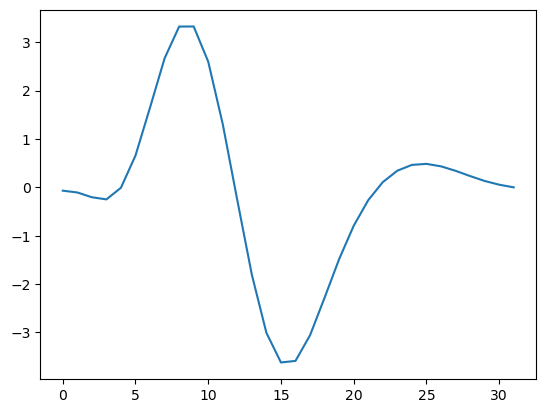

In [538]:
plt.figure()
plt.plot(EOF1)



In [588]:
time_idx_pos_test = np.where(PC1 >  PC1.std() * 2 + PC1.mean())
time_idx_neg_test = np.where(PC1 <  -PC1.std() * 2 + PC1.mean())

In [574]:
time_idx_pos_test[0]

array([ 1095,  1096,  1097, ..., 76482, 76483, 76484])

In [575]:
time_idx_pos[:]

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

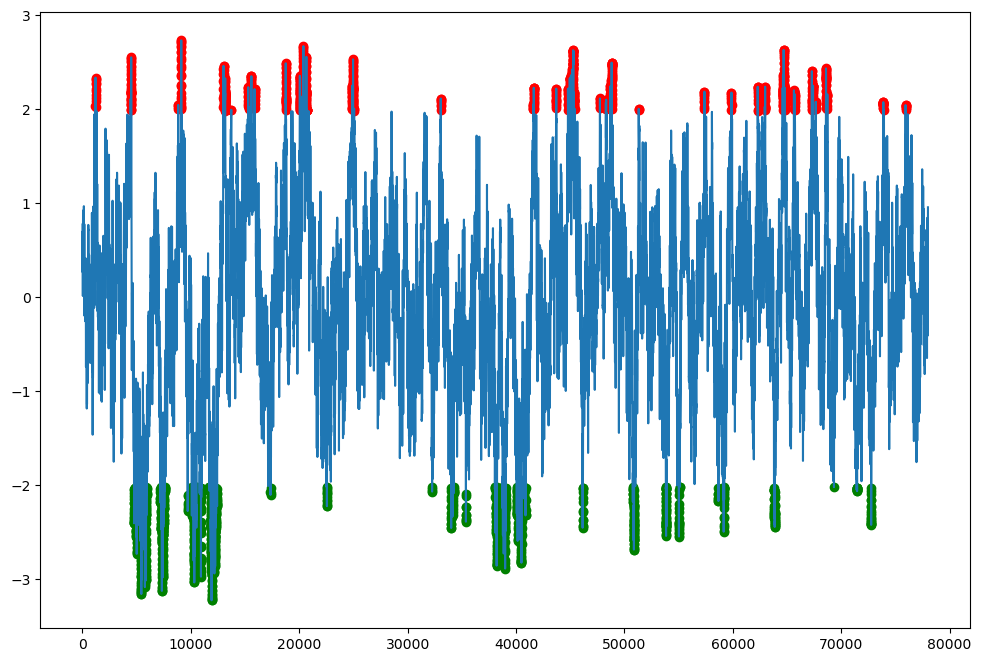

In [589]:
# Select the values from PC1[0] that satisfy the condition
PC1_big = PC1[time_idx_pos_test]
PC1_sml = PC1[time_idx_neg_test]

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx,yy = np.meshgrid(x,y)
days = np.linspace(0,78000,78000)

# Plot the data
plt.figure(figsize=(12,8), dpi=100.)
plt.plot(days, PC1)
plt.scatter(days[time_idx_pos_test], PC1_big, color="red")
# plt.scatter(days[PC1_big_indices[0]-500], PC1_big, color="Orange")
# plt.scatter(days[PC1_big_indices[0]-50], PC1_50[PC1_big_indices[0]-50], color="Purple")
# plt.scatter(days[PC1_big_indices[0]+100], PC1_50[PC1_big_indices[0]+100], color="Orange")


plt.scatter(days[time_idx_neg_test], PC1_sml, color="green")
plt.show()

In [532]:
u.shape

(78000, 20, 64, 128)

In [170]:
Fk.shape

(78000, 20, 64)

In [110]:
# # Re-import necessary libraries after reset
# import os
# import numpy as np
# import xarray as xr
# import h5py

def load_ep_flux_data(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        print(f.keys())
        Fj = f["f1"][:]  # (time, level, lat)
        Fk = f["f2"][:]
    return Fj, Fk

def composite_mean(F, time_idx_array, lags):
    # samples = []
    # for idx in time_idx_array:
    #     for lag in lags:
    #         t_idx = idx + lag
    #         t_idx [t_idx<F.shape[0]]
    #         if 0 <= t_idx < F.shape[0]:
    #             samples.append(F[t_idx])

    # print(len(samples))
    # return np.mean(samples, axis=0)
    samples = []
    for lag in lags:
        time_idx_array_lag = time_idx_array + lag
        time_idx_array_lag = time_idx_array_lag[time_idx_array_lag<F.shape[0]]
        samples.append(F[time_idx_array_lag].mean(axis=0))
    print(len(samples))
    return np.mean(samples, axis=0)
    

# Configuration
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"

pr_list = [10]
lags_5_20 = np.arange(10*4, 20*4+1, 1)
lags_30_60 = np.arange(90*4, 100*4+1, 1)

# Output
same_pr_ep_diff = {}

for pr in pr_list:
    print(f"\nLoading EP flux data for PR={pr}...")
    Fj, Fk = load_ep_flux_data(pr, save_dir)

    print(f"Loading time indices for PR={pr}...")
    time_idx_pos = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{pr}.npy")
    time_idx_neg = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{pr}.npy")
    print(time_idx_pos.shape)
    print(time_idx_neg.shape)
    
    print("--> Computing EP+ composite...")
    ep1_pos = composite_mean(Fj, time_idx_pos, lags_5_20)
    ep2_pos = composite_mean(Fk, time_idx_pos, lags_5_20)
    ep1_far_pos = composite_mean(Fj, time_idx_pos, lags_30_60)
    ep2_far_pos = composite_mean(Fk, time_idx_pos, lags_30_60)

    EP_plus   = ep1_pos - ep1_far_pos
    EP_plus_p = ep2_pos - ep2_far_pos

    print("--> Computing EP- composite...")
    ep1_neg = composite_mean(Fj, time_idx_neg, lags_5_20)
    ep2_neg = composite_mean(Fk, time_idx_neg, lags_5_20)
    ep1_far_neg = composite_mean(Fj, time_idx_neg, lags_30_60)
    ep2_far_neg = composite_mean(Fk, time_idx_neg, lags_30_60)

    EP_minus   = ep1_neg - ep1_far_neg
    EP_minus_p = ep2_neg - ep2_far_neg

    diff_phi = EP_plus   - EP_minus
    diff_p   = EP_plus_p - EP_minus_p

    same_pr_ep_diff[pr] = (diff_phi, diff_p)

    # Create xarray Dataset and save
    level = np.linspace(1000, 100000, diff_phi.shape[0])
    lat = np.linspace(-90, 90, diff_phi.shape[1])
    ds = xr.Dataset({
        f"EP_phi_diff_PR{pr}": (["level", "lat"], diff_phi),
        f"EP_p_diff_PR{pr}":   (["level", "lat"], diff_p)
    }, coords={"level": level, "lat": lat})

    save_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR10.nc"
    print(f"Saving composite diff to {save_path}...")
    ds.to_netcdf(save_path)
    print("✓ Save complete.")



Loading EP flux data for PR=10...
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
Loading time indices for PR=10...
(13189,)
(12417,)
--> Computing EP+ composite...
41
41
41
41
--> Computing EP- composite...
41
41
41
41
Saving composite diff to /data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR10.nc...
✓ Save complete.


In [49]:
lags_30_60

array([360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372,
       373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385,
       386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398,
       399, 400])

## Try to plot same pr ep diff

In [111]:
def load_ep_flux_data_same_pr(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"same_pr_ep_diff_PR{pr}.nc"), "r") as f:
        print(f.keys())
        Fj = f[f"EP_p_diff_PR{pr}"][:]  # (time, level, lat)
        Fk = f[f"EP_phi_diff_PR{pr}"][:]
    return Fj, Fk

In [27]:
def load_ep_flux_data(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        print(f.keys())
        Fj = f["f1"][:]  # (time, level, lat)
        Fk = f["f2"][:]
        level = f["level"][:]
        time  = f["time"][:]
    return Fj, Fk, level, time

In [113]:
save_dir_same_pr = "/data92/PeterChang/back_to_master1220/Moist_Dycore/"

# pr = 0
Fj_pr0, Fk_pr0   = load_ep_flux_data_same_pr(0, save_dir_same_pr)
Fj_pr10, Fk_pr10 = load_ep_flux_data_same_pr(10, save_dir_same_pr)
Fj_pr20, Fk_pr20 = load_ep_flux_data_same_pr(20, save_dir_same_pr)
Fj_pr30, Fk_pr30 = load_ep_flux_data_same_pr(30, save_dir_same_pr)
Fj_pr40, Fk_pr40 = load_ep_flux_data_same_pr(40, save_dir_same_pr)
Fj_pr50, Fk_pr50 = load_ep_flux_data_same_pr(50, save_dir_same_pr)




<KeysViewHDF5 ['EP_p_diff_PR0', 'EP_phi_diff_PR0', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR10', 'EP_phi_diff_PR10', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR20', 'EP_phi_diff_PR20', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR30', 'EP_phi_diff_PR30', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR40', 'EP_phi_diff_PR40', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR50', 'EP_phi_diff_PR50', 'lat', 'level']>


In [28]:
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
Fj_pr0, Fk_pr0, level, time   = load_ep_flux_data(0, save_dir)
Fj_pr10, Fk_pr10, level, time = load_ep_flux_data(10, save_dir)
Fj_pr20, Fk_pr20, level, time = load_ep_flux_data(20, save_dir)
Fj_pr30, Fk_pr30, level, time = load_ep_flux_data(30, save_dir)
Fj_pr40, Fk_pr40, level, time = load_ep_flux_data(40, save_dir)
Fj_pr50, Fk_pr50, level, time = load_ep_flux_data(50, save_dir)

<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>


In [114]:
Fj_pr0.shape

(20, 64)

In [503]:
Fj_mean_pr0 = Fj_pr0.mean(axis=0)
Fk_mean_pr0 = Fk_pr0.mean(axis=0)

Fj_mean_pr10 = Fj_pr10.mean(axis=0)
Fk_mean_pr10 = Fk_pr10.mean(axis=0)

Fj_mean_pr20 = Fj_pr20.mean(axis=0)
Fk_mean_pr20 = Fk_pr20.mean(axis=0)

Fj_mean_pr30 = Fj_pr30.mean(axis=0)
Fk_mean_pr30 = Fk_pr30.mean(axis=0)

Fj_mean_pr40 = Fj_pr40.mean(axis=0)
Fk_mean_pr40 = Fk_pr40.mean(axis=0)

Fj_mean_pr50 = Fj_pr50.mean(axis=0)
Fk_mean_pr50 = Fk_pr50.mean(axis=0)
# Fj_mean = Fj_pr0
# Fk_mean = Fk_pr0



In [500]:
Fj_mean_diff_pr10 = Fj_mean_pr10 - Fj_mean_pr0
Fk_mean_diff_pr10 = Fk_mean_pr10 - Fk_mean_pr0

Fj_mean_diff_pr20 = Fj_mean_pr20 - Fj_mean_pr0
Fk_mean_diff_pr20 = Fk_mean_pr20 - Fk_mean_pr0

Fj_mean_diff_pr30 = Fj_mean_pr30 - Fj_mean_pr0
Fk_mean_diff_pr30 = Fk_mean_pr30 - Fk_mean_pr0

Fj_mean_diff_pr40 = Fj_mean_pr40 - Fj_mean_pr0
Fk_mean_diff_pr40 = Fk_mean_pr40 - Fk_mean_pr0

Fj_mean_diff_pr50 = Fj_mean_pr50 - Fj_mean_pr0
Fk_mean_diff_pr50 = Fk_mean_pr50 - Fk_mean_pr0


In [53]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj_mean_diff_pr50**2 + Fk_mean_diff_pr50**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 20 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)
      
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_mean_diff_pr50[::, ::], -Fk_mean_diff_pr50[::, ::],
    color="black", width=3e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)
ax.set_yscale("log")
plt.gca().invert_yaxis()
ax.set_xlim([0, 90])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


NameError: name 'Fj_mean_diff_pr50' is not defined

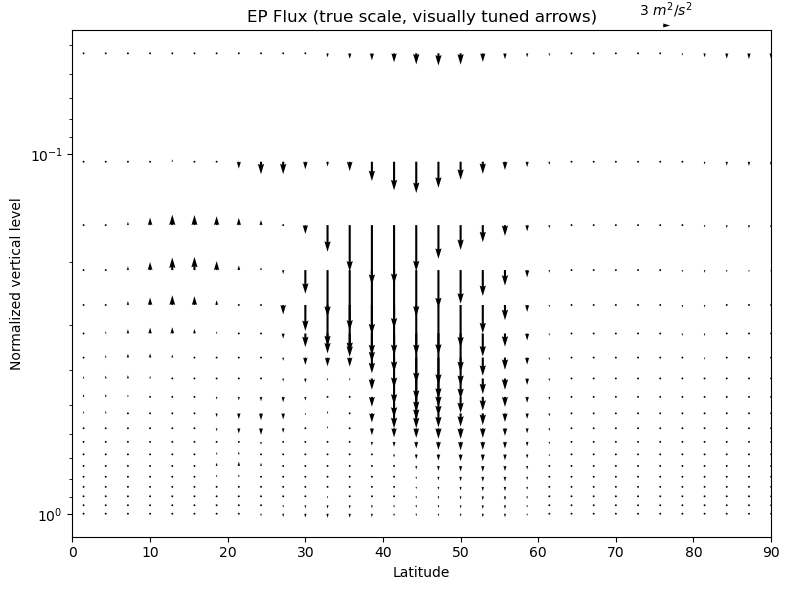

In [115]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt((Fj_pr50 - Fj_pr0)**2 + (Fk_pr50 - Fk_pr0)**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 100 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)
      
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_pr50 - Fj_pr0[::, ::], -(Fk_pr50 - Fk_pr0)[::, ::],
    color="black", width=3e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_yscale("log")
plt.gca().invert_yaxis()
ax.set_xlim([0, 90])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [613]:
Fj_pr0.shape

(20, 64)

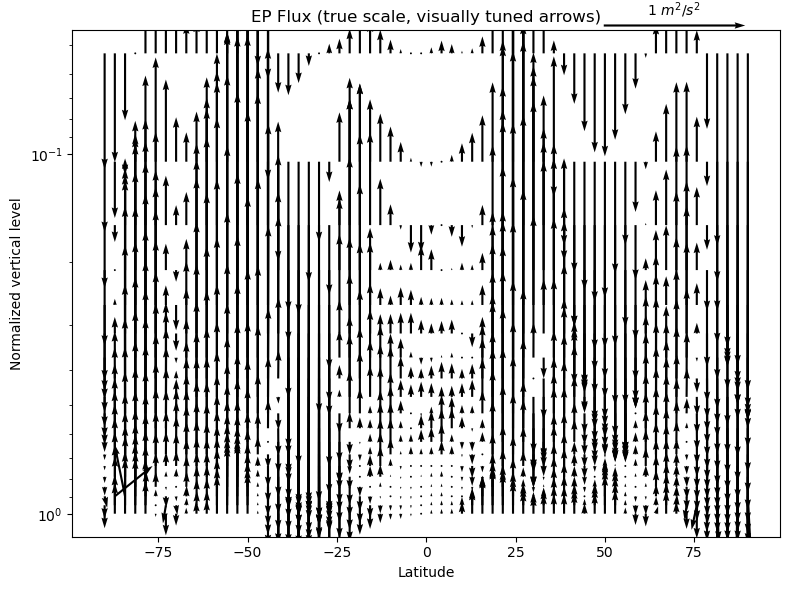

In [119]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt((Fj_pr0[::, ::]**2 + (Fk_pr0[::, ::])**2))
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 5 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)
      
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_pr0[::, ::], (Fk_pr0)[::, ::],
    color="black", width=3e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_yscale("log")
plt.gca().invert_yaxis()
# ax.set_xlim([0, 90])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [524]:
Fj_pr0.shape[-2]

20

Drawing for PR=0...


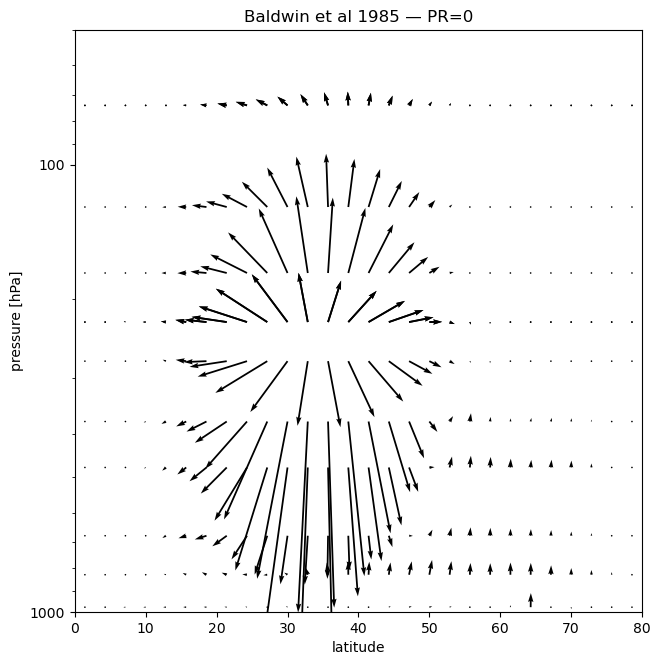

Drawing for PR=10...


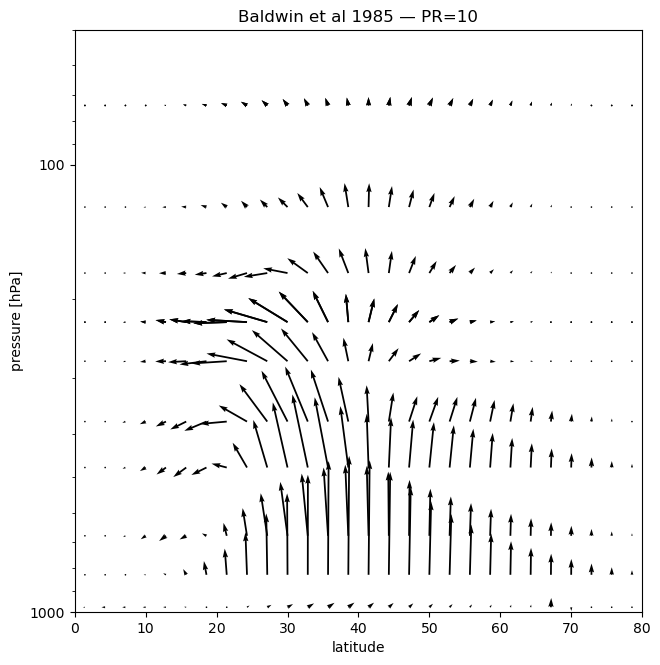

Drawing for PR=20...


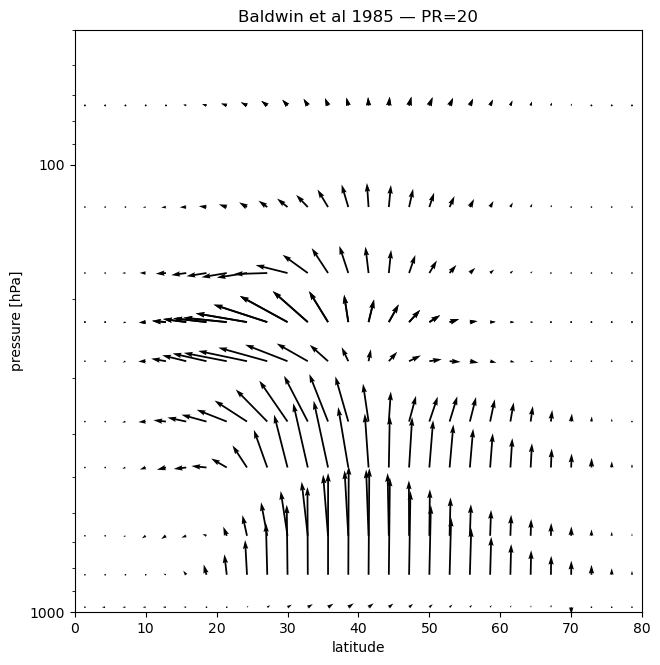

Drawing for PR=30...


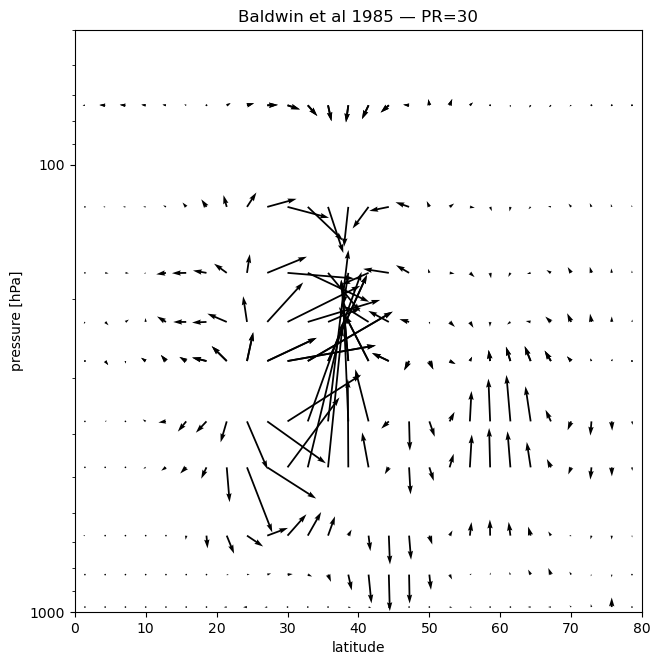

Drawing for PR=40...


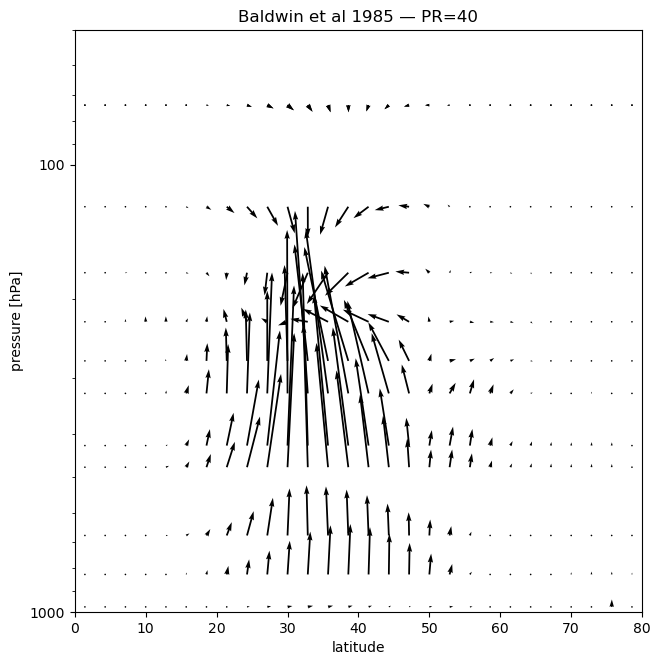

Drawing for PR=50...


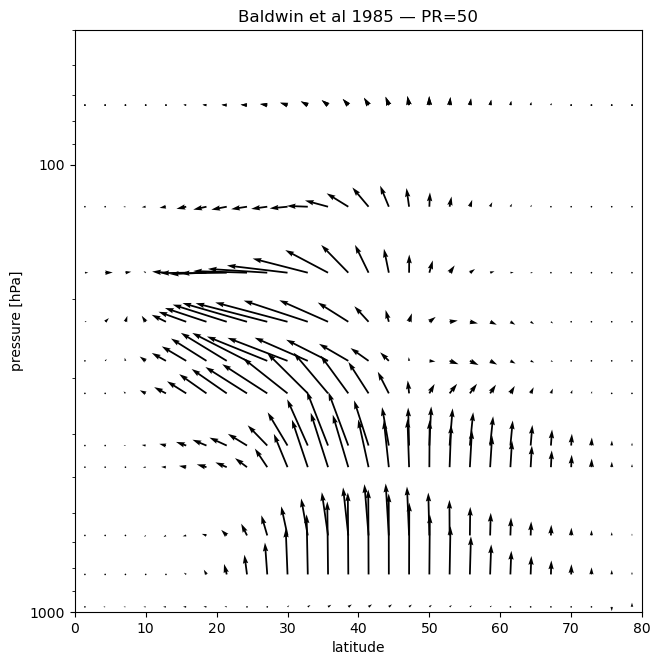

In [121]:
import sys
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py

# 加入 Jucker 函數庫
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# === 設定 ===
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
lat = np.linspace(-90, 90, 64)
pres = np.array([10,50,70,100,150,200,250,300,400,500,700,850,1000])

lat_sel = lat[(lat >= 0) & (lat <= 80)]

# === Loop over PR ===
for pr in range(0, 60, 10):
    print(f"Drawing for PR={pr}...")

    # 載入資料
    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        Fj = f["f1"][:]  # (time, level, lat)
        Fk = f["f2"][:]
        level = f["level"][:]  # 儲存在 HDF5 裡的 pressure level

    # 轉成 xarray
    Fj_xr = xr.DataArray(Fj.mean(axis=0), dims=["level", "latitude"],
                         coords={"level": level, "latitude": lat})
    Fk_xr = xr.DataArray(Fk.mean(axis=0), dims=["level", "latitude"],
                         coords={"level": level, "latitude": lat})

    # 畫圖
    fig, ax = plt.subplots()
    set_size(5.2, 5.2, ax)

    _, _ = ac.PlotEPfluxArrows(
        Fj_xr.sel(latitude=lat_sel, level=pres, method='nearest').latitude,
        Fk_xr.sel(level=pres, method='nearest').level,
        Fj_xr.sel(latitude=lat_sel, level=pres, method='nearest'),
        -Fk_xr.sel(latitude=lat_sel, level=pres, method='nearest'),
        fig, ax,
        xlim=[0, 80], ylim=[1000, 50], yscale='log'
    )

    ax.get_children()[1].set_facecolor('r')
    ax.set_title(f"Baldwin et al 1985 — PR={pr}")
    ax.set_xlabel("latitude")
    ax.set_ylabel("pressure [hPa]")
    ax.yaxis.set_major_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    # 如果要儲存：
    # plt.savefig(f"EPflux_PR{pr}.png", dpi=300)
    plt.show()
